# Bank Marketing Campaign - Predictive Modeling for Term Deposit Subscriptions

**Data Analytics Micro Project - Topic 4**

**Objective:** Build a classification model to predict whether a client will subscribe to a term deposit based on demographic, financial, and campaign-related features. Help the bank refocus marketing efforts on high-potential customers.

See readme or our presentation for more details about our approaches.

## 1. Imports and Setup

In [1]:
# ============================================================
# Core data manipulation and numerical libraries
# ============================================================
import pandas as pd
import numpy as np

# ============================================================
# Visualization libraries
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn: model selection and preprocessing
# ============================================================
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# Scikit-learn: evaluation metrics
# ============================================================
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score, accuracy_score,
                             precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve

# ============================================================
# Imbalanced-learn: SMOTE for oversampling the minority class
# ============================================================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ============================================================
# XGBoost: gradient boosting for tabular data
# ============================================================
import xgboost as xgb

# ============================================================
# SHAP: model interpretability (game-theoretic feature attribution)
# ============================================================
import shap

# Suppress non-critical warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style across all visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

/Users/devsimsek/Library/smskworks/SchoolWorks/tha/data-analytics/micro-project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading

In [2]:
# ============================================================
# Load the ENRICHED UCI Bank Marketing dataset (bank-additional-full.csv)
# This version includes 5 social/economic indicators from Banco de Portugal:
#   emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed
#   + day_of_week (last contact day of the week)
# Source: [Moro et al., 2014] https://archive.ics.uci.edu/dataset/222/bank+marketing
# Note: semicolon-separated, pdays=999 means "not previously contacted"
# ============================================================
df = pd.read_csv('data/bank-additional-full.csv', sep=';')

# Quick sanity check on dataset dimensions
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.shape[1]} | Rows: {df.shape[0]}')
print(f'Date range: {df["month"].iloc[0]} (first) to {df["month"].iloc[-1]} (last) - ordered chronologically')

# Preview first 5 rows to inspect column names, types, and sample values
df.head()

Dataset shape: (41188, 21)
Columns: 21 | Rows: 41188
Date range: may (first) to nov (last) - ordered chronologically


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Data Understanding & Cleanup

### 3.1 Basic Information & Data Types

In [3]:
# Display column data types, non-null counts, and memory usage
# This helps identify which columns need encoding and whether any have missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
# Summary statistics for numerical columns (count, mean, std, quartiles, min, max)
# Transposed and styled with a gradient for easier scanning
df.describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
age,41188.000000,40.024060,10.421250,17.000000,32.000000,38.000000,47.000000,98.000000
duration,41188.000000,258.285010,259.279249,0.000000,102.000000,180.000000,319.000000,4918.000000
campaign,41188.000000,2.567593,2.770014,1.000000,1.000000,2.000000,3.000000,56.000000
pdays,41188.000000,962.475454,186.910907,0.000000,999.000000,999.000000,999.000000,999.000000
previous,41188.000000,0.172963,0.494901,0.000000,0.000000,0.000000,0.000000,7.000000
emp.var.rate,41188.000000,0.081886,1.570960,-3.400000,-1.800000,1.100000,1.400000,1.400000
cons.price.idx,41188.000000,93.575664,0.578840,92.201000,93.075000,93.749000,93.994000,94.767000
cons.conf.idx,41188.000000,-40.502600,4.628198,-50.800000,-42.700000,-41.800000,-36.400000,-26.900000
euribor3m,41188.000000,3.621291,1.734447,0.634000,1.344000,4.857000,4.961000,5.045000
nr.employed,41188.000000,5167.035911,72.251528,4963.600000,5099.100000,5191.000000,5228.100000,5228.100000


In [5]:
# Check for two types of missing data in this dataset:
# 1. Actual NaN/null values
# 2. "unknown" string placeholders - treated as a meaningful category
# The enriched dataset (bank-additional-full.csv) uses "unknown" for missing
# categorical values; economic features are complete (no missing values)
print('=== Missing values ===')
print(df.isnull().sum())
print('\n=== "unknown" values per column ===')
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f'{col}: {unknown_count} ({unknown_count/len(df)*100:.1f}%)')

=== Missing values ===
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

=== "unknown" values per column ===
job: 330 (0.8%)
marital: 80 (0.2%)
education: 1731 (4.2%)
default: 8597 (20.9%)
housing: 990 (2.4%)
loan: 990 (2.4%)


### 3.2 Categorical vs Numerical Feature Split

In [6]:
# Separate columns into categorical and numerical groups
# Exclude target variable 'y' from feature lists
# New in enriched dataset: day_of_week (cat) + 5 economic indicators (num)
categorical_cols = df.select_dtypes(include='object').columns.drop('y').tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')
print(f'Numerical features ({len(numerical_cols)}): {numerical_cols}')
print(f'\nEconomic indicators: emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed')
print(f'New categorical feature: day_of_week')

Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical features (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Economic indicators: emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed
New categorical feature: day_of_week


### 3.3 Exploratory Data Analysis

**Target Variable Distribution** - the class imbalance is immediately apparent.

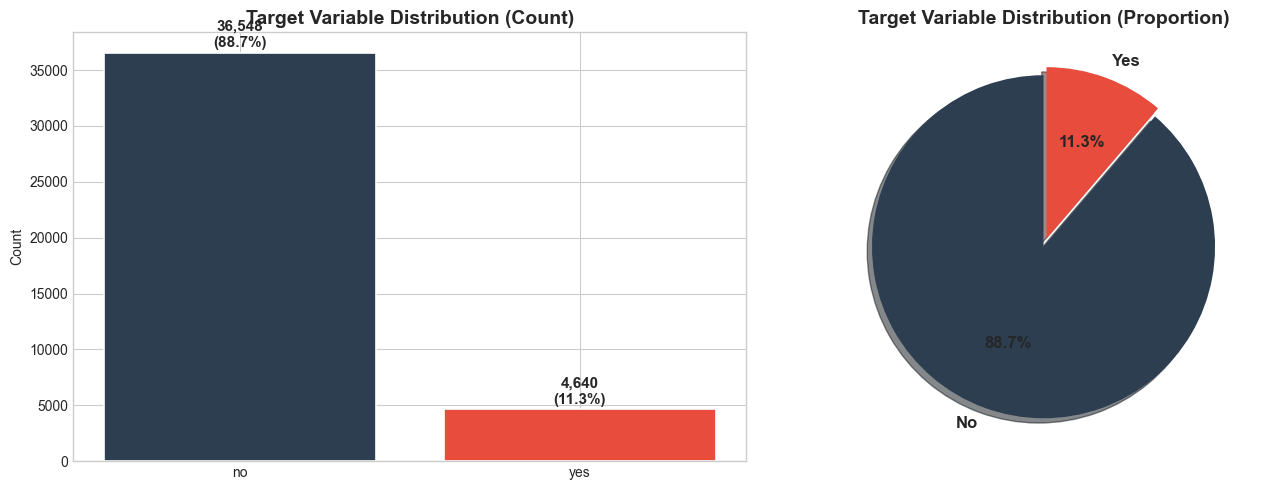

In [7]:
# ============================================================
# Visualize the target variable (y) - subscription outcome
# Left: count plot showing the severe class imbalance
# Right: pie chart for proportional view
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot with value labels
colors = ['#2c3e50', '#e74c3c']
counts = df['y'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Target Variable Distribution (Count)', fontsize=14, fontweight='bold')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 500, f'{val:,}\n({val/len(df)*100:.1f}%)',
                ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart - makes the 88/12 imbalance immediately visible
axes[1].pie(counts.values, labels=['No', 'Yes'], autopct='%1.1f%%',
           colors=colors, explode=(0, 0.05), shadow=True, startangle=90,
           textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Target Variable Distribution (Proportion)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Numerical Feature Distributions by Target** - comparing subscribers vs non-subscribers.

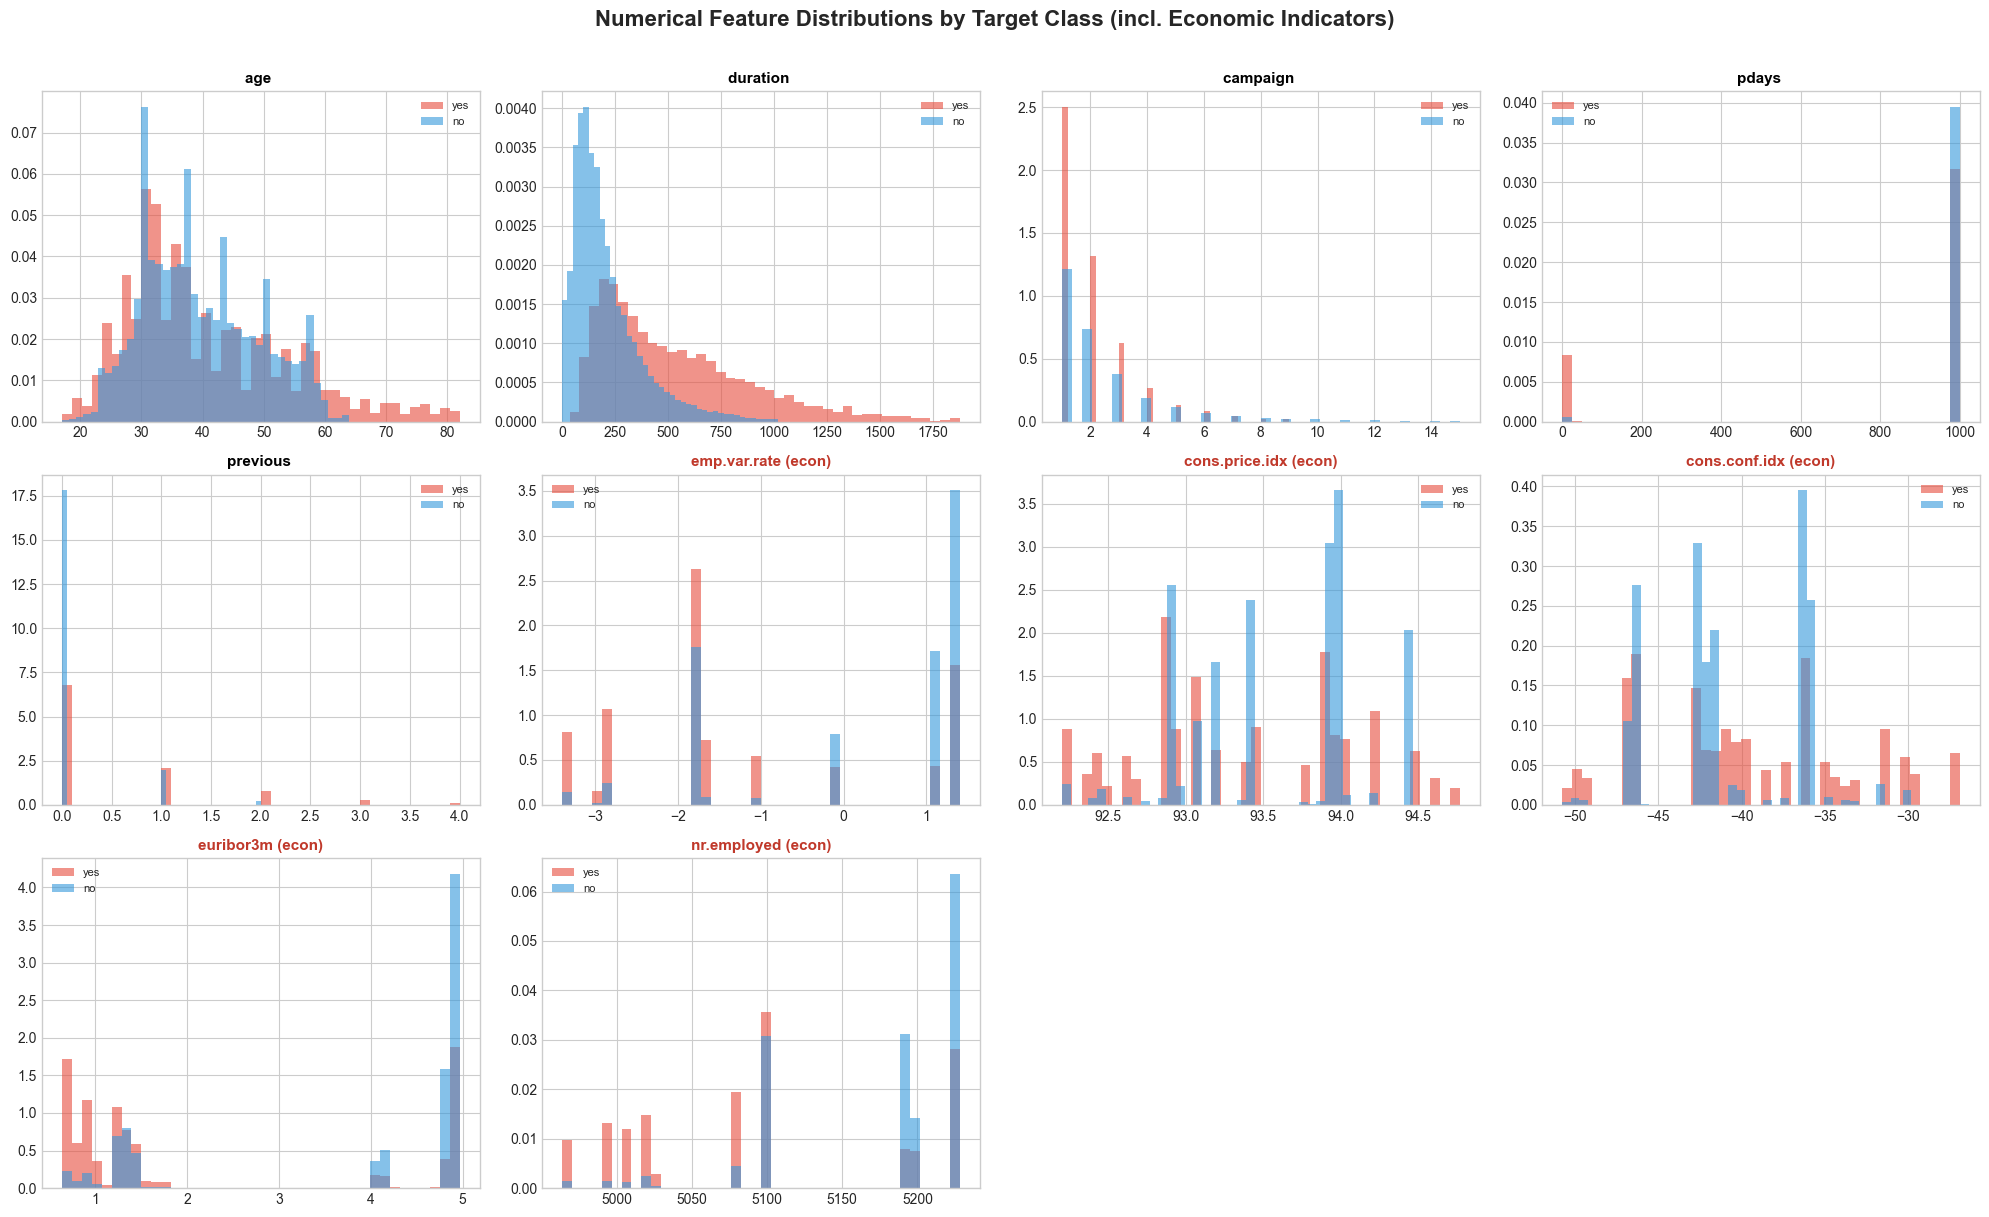

In [8]:
# ============================================================
# Plot each numerical feature's distribution separately for
# subscribers (yes) vs non-subscribers (no)
# Values are capped at the 99th percentile to avoid extreme outliers skewing the view
# Now includes 5 economic indicators (12 features total -> 4*3 grid)
# ============================================================
n_num = len(numerical_cols)
n_cols = 4
n_rows = int(np.ceil(n_num / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    for label, color in zip(['yes', 'no'], ['#e74c3c', '#3498db']):
        subset = df[df['y'] == label][col]
        # Cap at 99th percentile to prevent outliers from stretching the x-axis
        cap = subset.quantile(0.99)
        subset_clipped = subset[subset <= cap]
        ax.hist(subset_clipped, bins=40, alpha=0.6, label=label, color=color, density=True)
    # Highlight economic indicators with a different title color
    is_economic = col in ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
    title_color = '#c0392b' if is_economic else 'black'
    ax.set_title(f'{col} {"(econ)" if is_economic else ""}', fontsize=11, fontweight='bold', color=title_color)
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(n_num, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Target Class (incl. Economic Indicators)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Categorical Features vs Subscription Rate** - which demographics and attributes correlate with higher conversion?

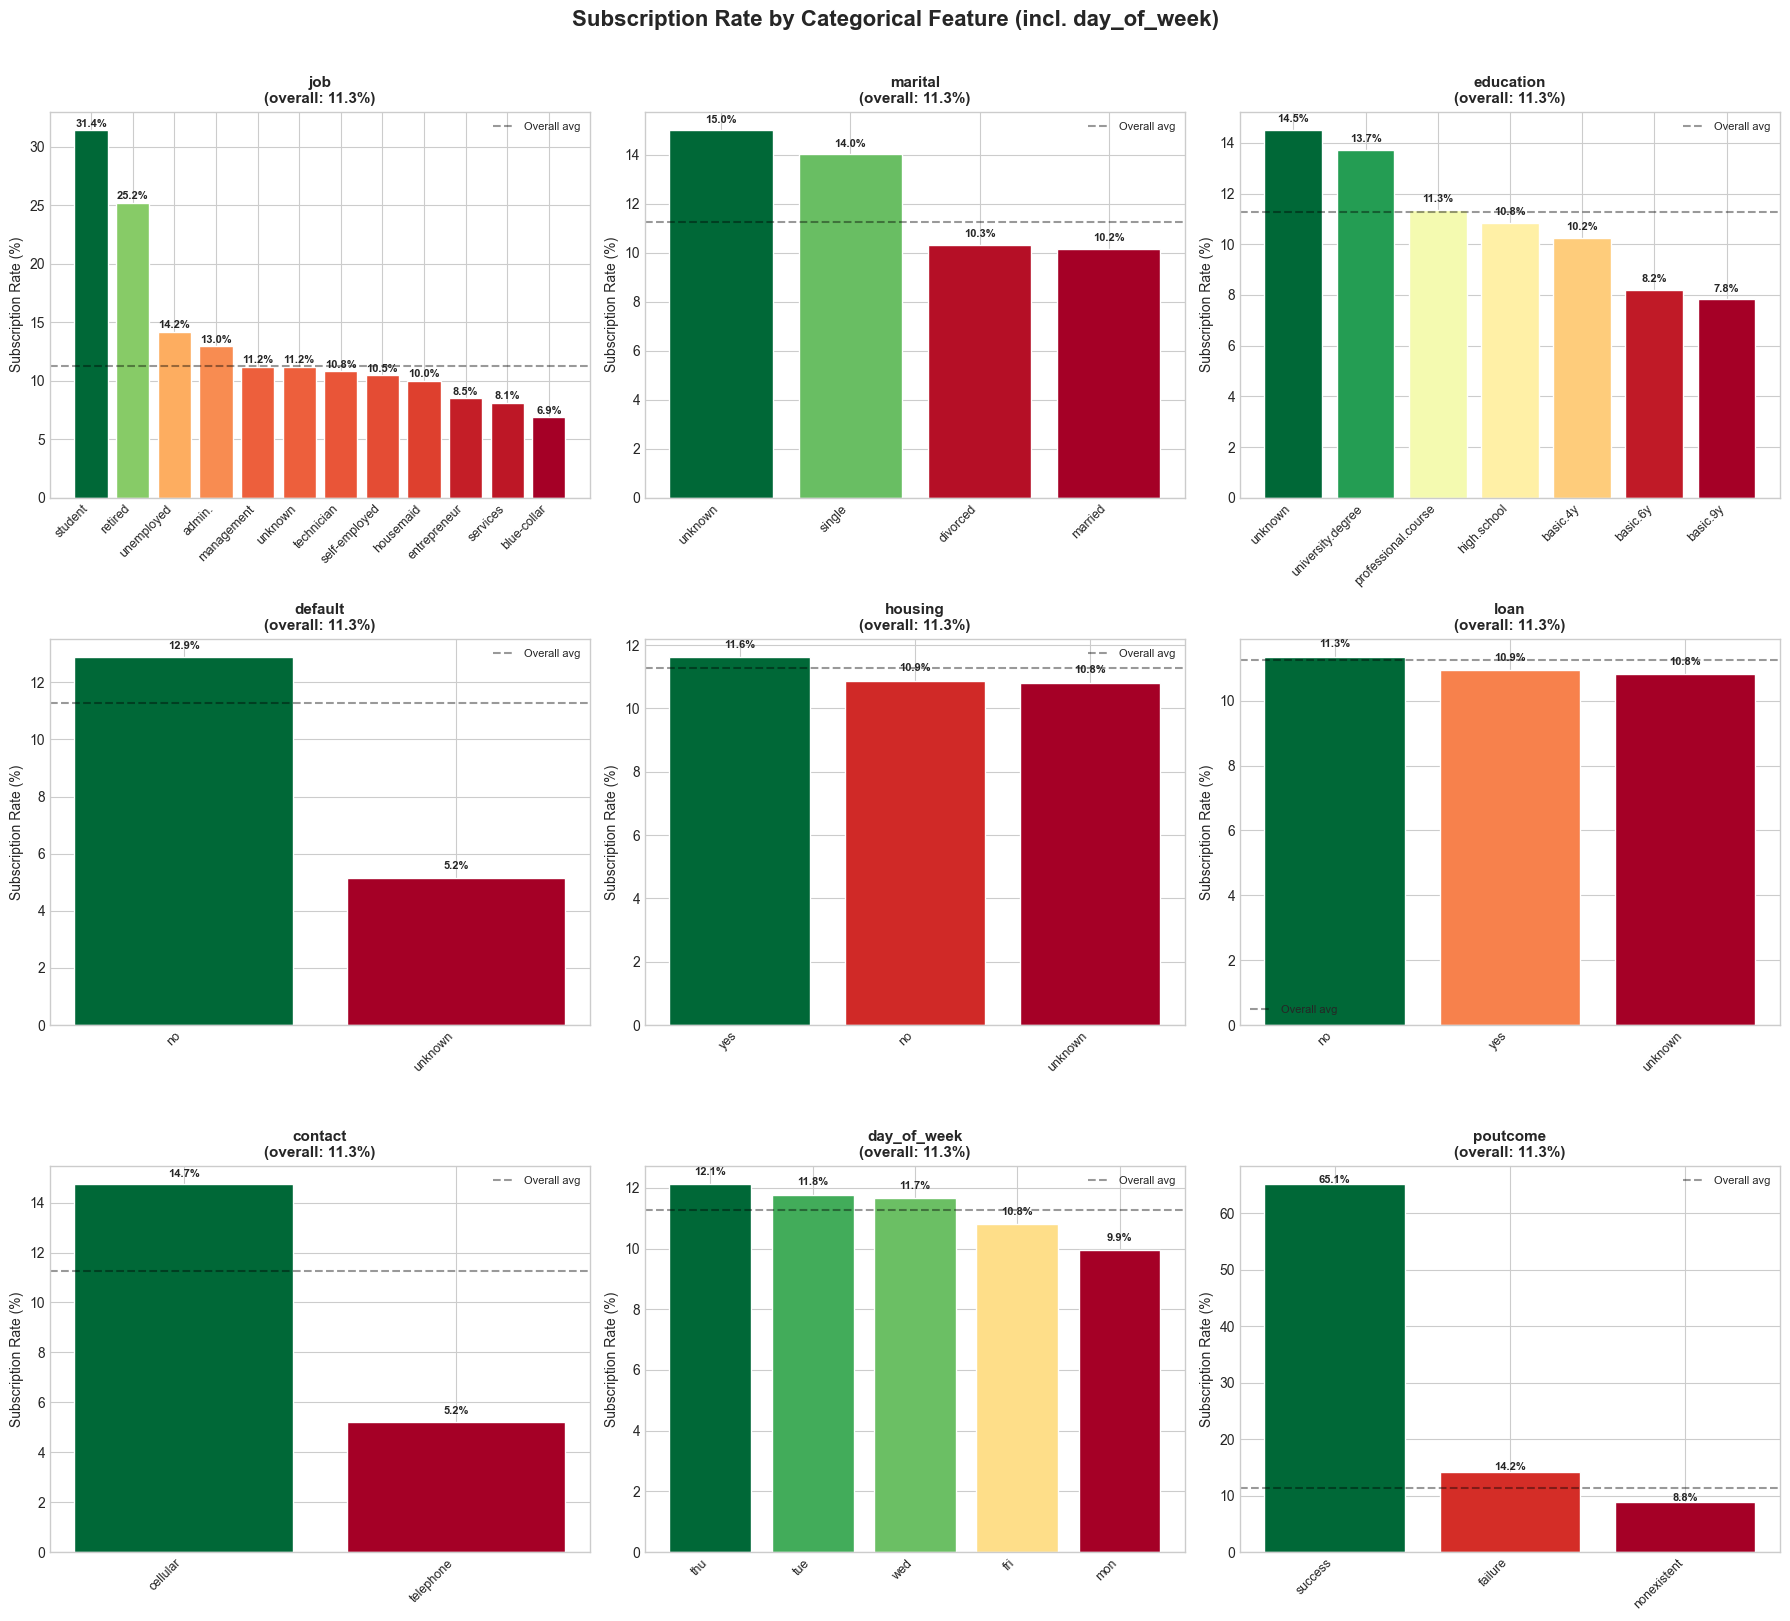

In [9]:
# ============================================================
# Analyze how subscription rates vary across categorical features
# Each bar = a category; color gradient from red (low) to green (high)
# Horizontal dashed line = overall average subscription rate
# Only categories with > 30 observations are displayed to avoid noise
# Now includes day_of_week (enriched dataset)
# ============================================================
cat_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day_of_week', 'poutcome']

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ax = axes[i]
    # Compute subscription rate (percentage of 'yes') for each category
    rates = df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
    counts = df[col].value_counts()
    rates = rates[rates.index.isin(counts[counts > 30].index)]  # filter out categories with very few samples

    # Color bars by rate: red = low, green = high
    cmap = plt.get_cmap('RdYlGn')
    bar_colors = cmap([(v - rates.min()) / (rates.max() - rates.min()) if rates.max() > rates.min() else 0.5 for v in rates.values])
    bars = ax.bar(range(len(rates)), rates.values, color=bar_colors, edgecolor='white')
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{col}\n(overall: {df["y"].eq("yes").mean()*100:.1f}%)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Subscription Rate (%)')
    ax.axhline(y=df['y'].eq('yes').mean() * 100, color='black', linestyle='--', alpha=0.4, label='Overall avg')
    ax.legend(fontsize=8)

    # Add percentage labels on top of each bar
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

# All 9 slots used now (8 features + poutcome)
plt.suptitle('Subscription Rate by Categorical Feature (incl. day_of_week)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Correlation Analysis** - numerical feature relationships.

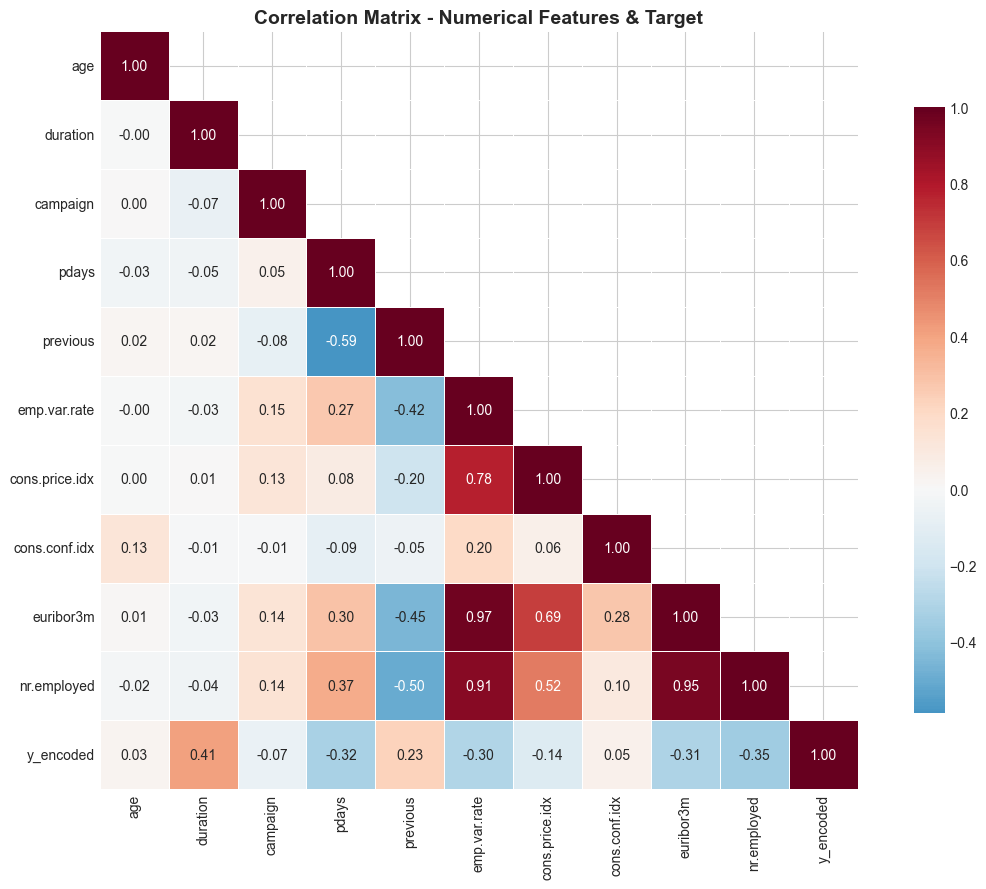

In [10]:
# ============================================================
# Correlation heatmap - numerical features + encoded target
# Upper triangle masked to avoid redundancy
# Red-blue diverging colormap centered at 0
# ============================================================
plt.figure(figsize=(12, 9))
df['y_encoded'] = df['y'].map({'yes': 1, 'no': 0})
corr_matrix = df[numerical_cols + ['y_encoded']].copy()
corr = corr_matrix.corr()

# Mask the upper triangle to show each pair only once
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Numerical Features & Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Duration Analysis** - campaign call duration is known to be the single strongest predictor. We'll note this and build models both with and without it.

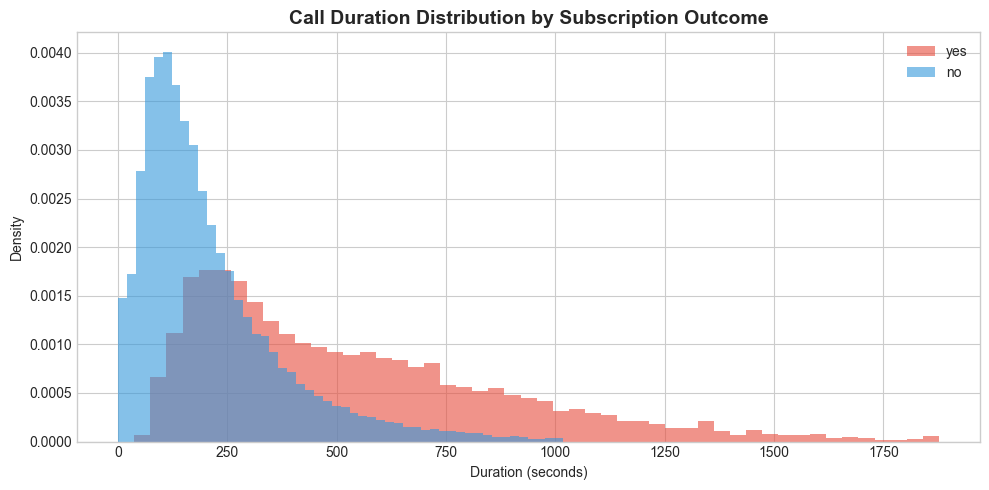

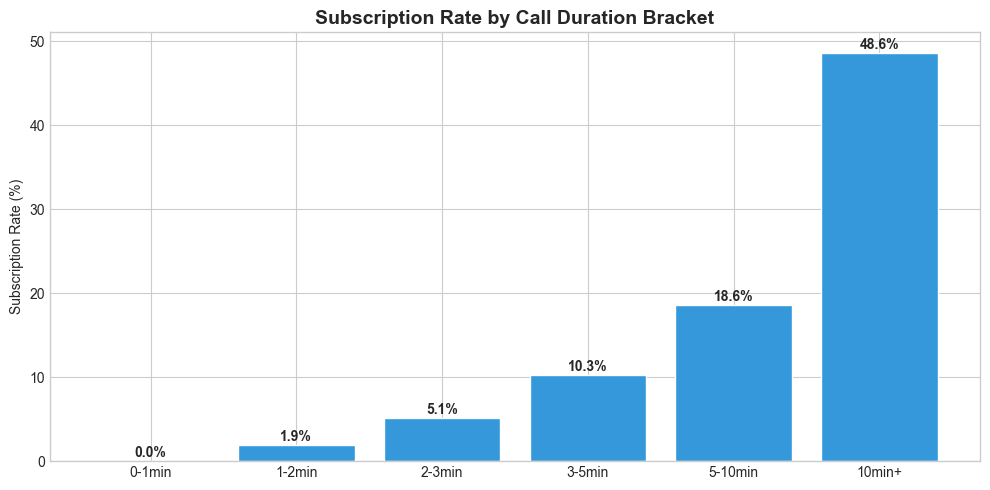

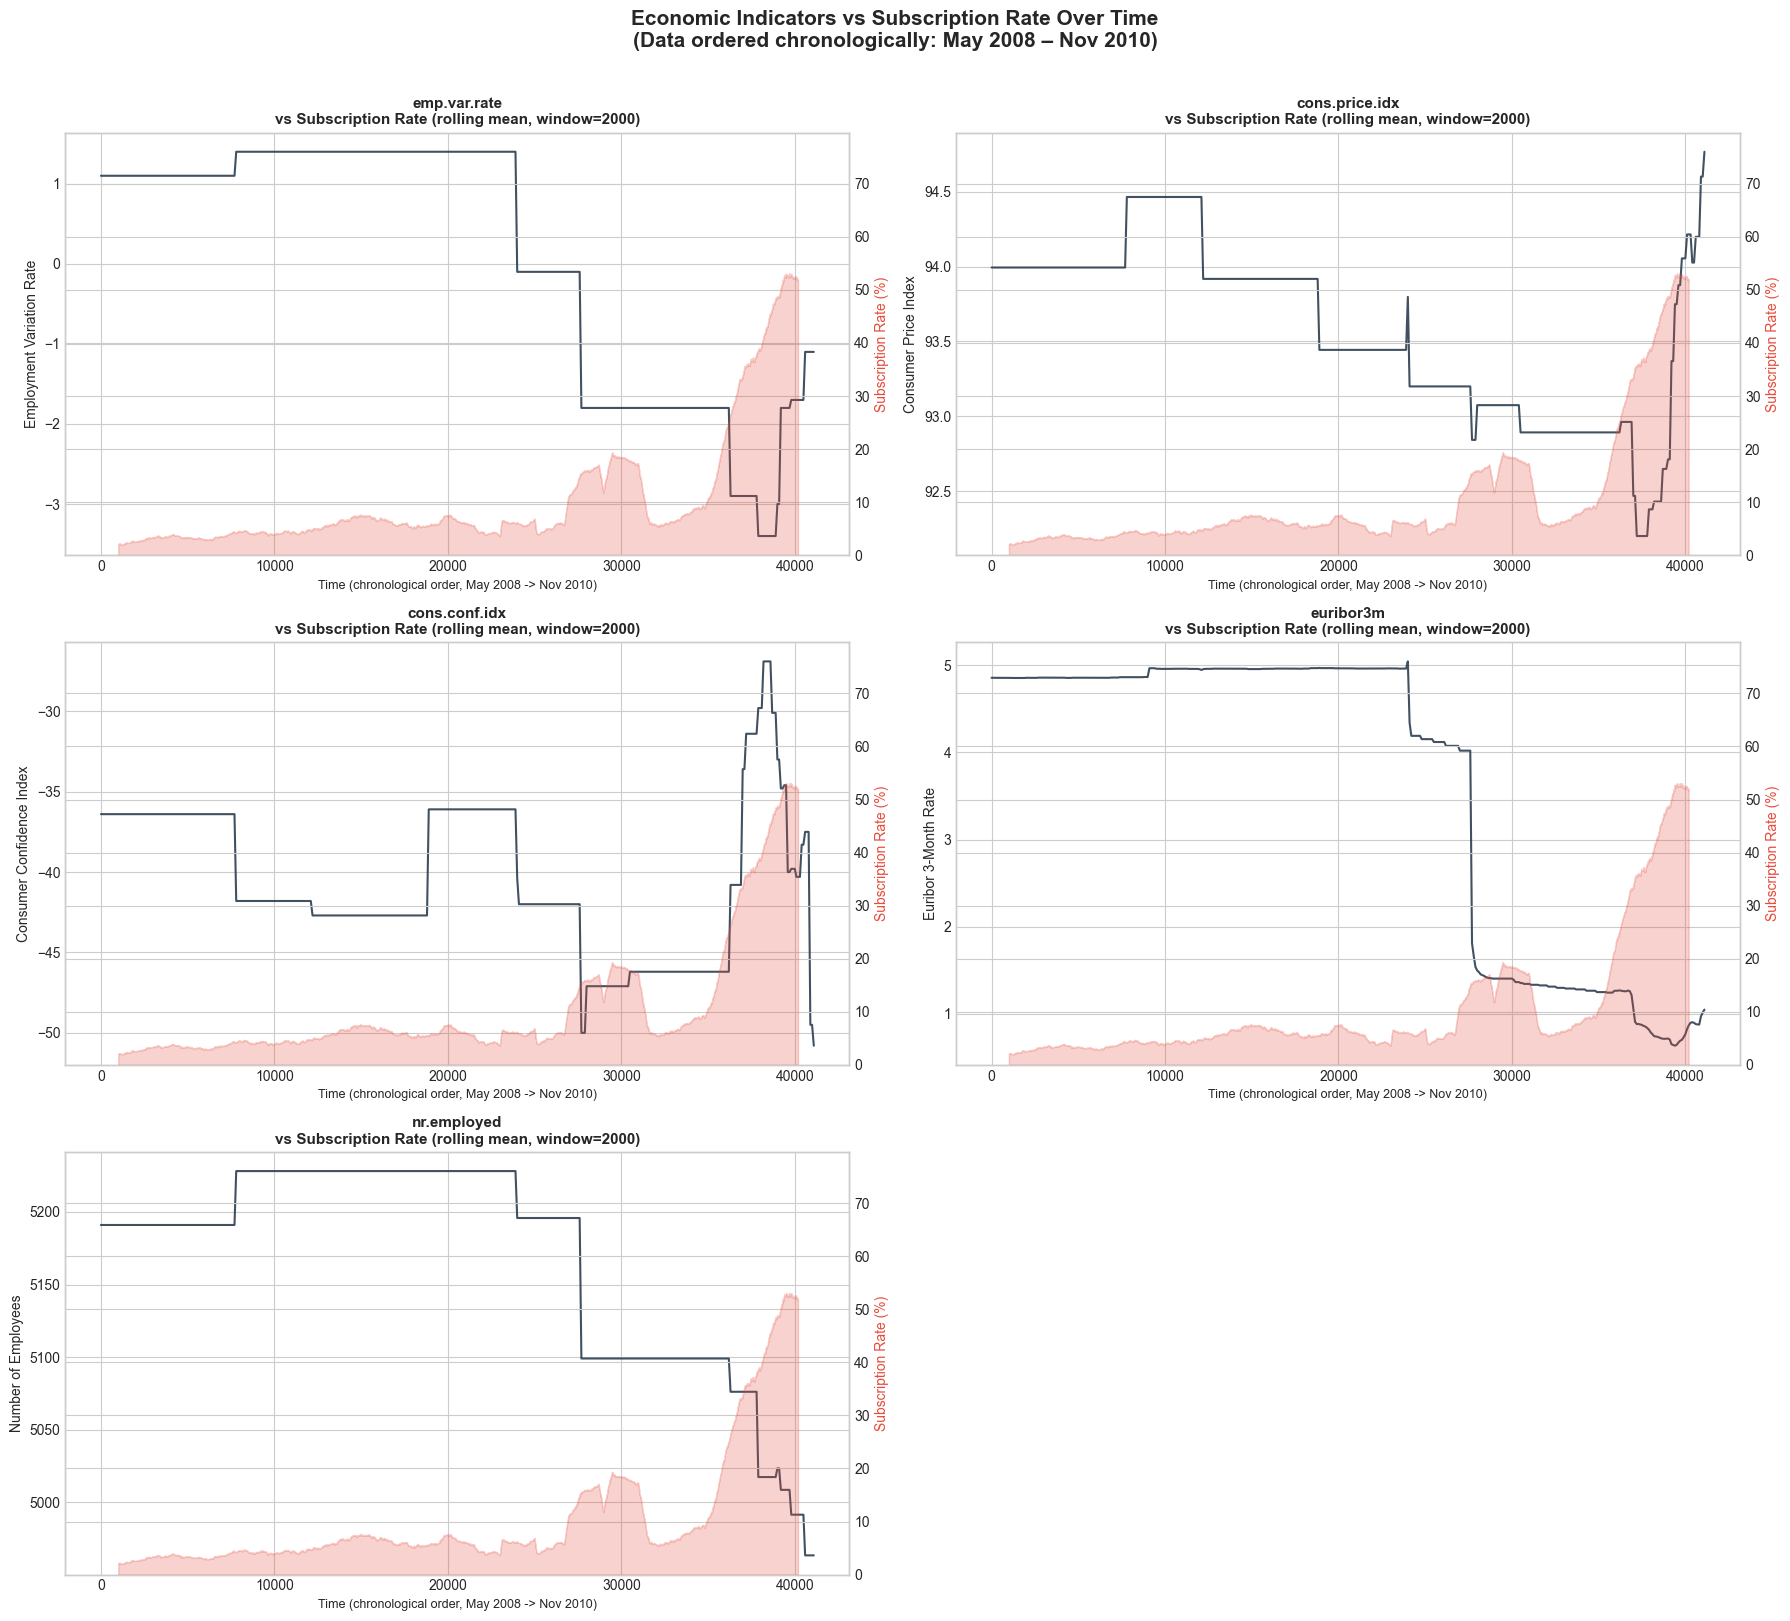

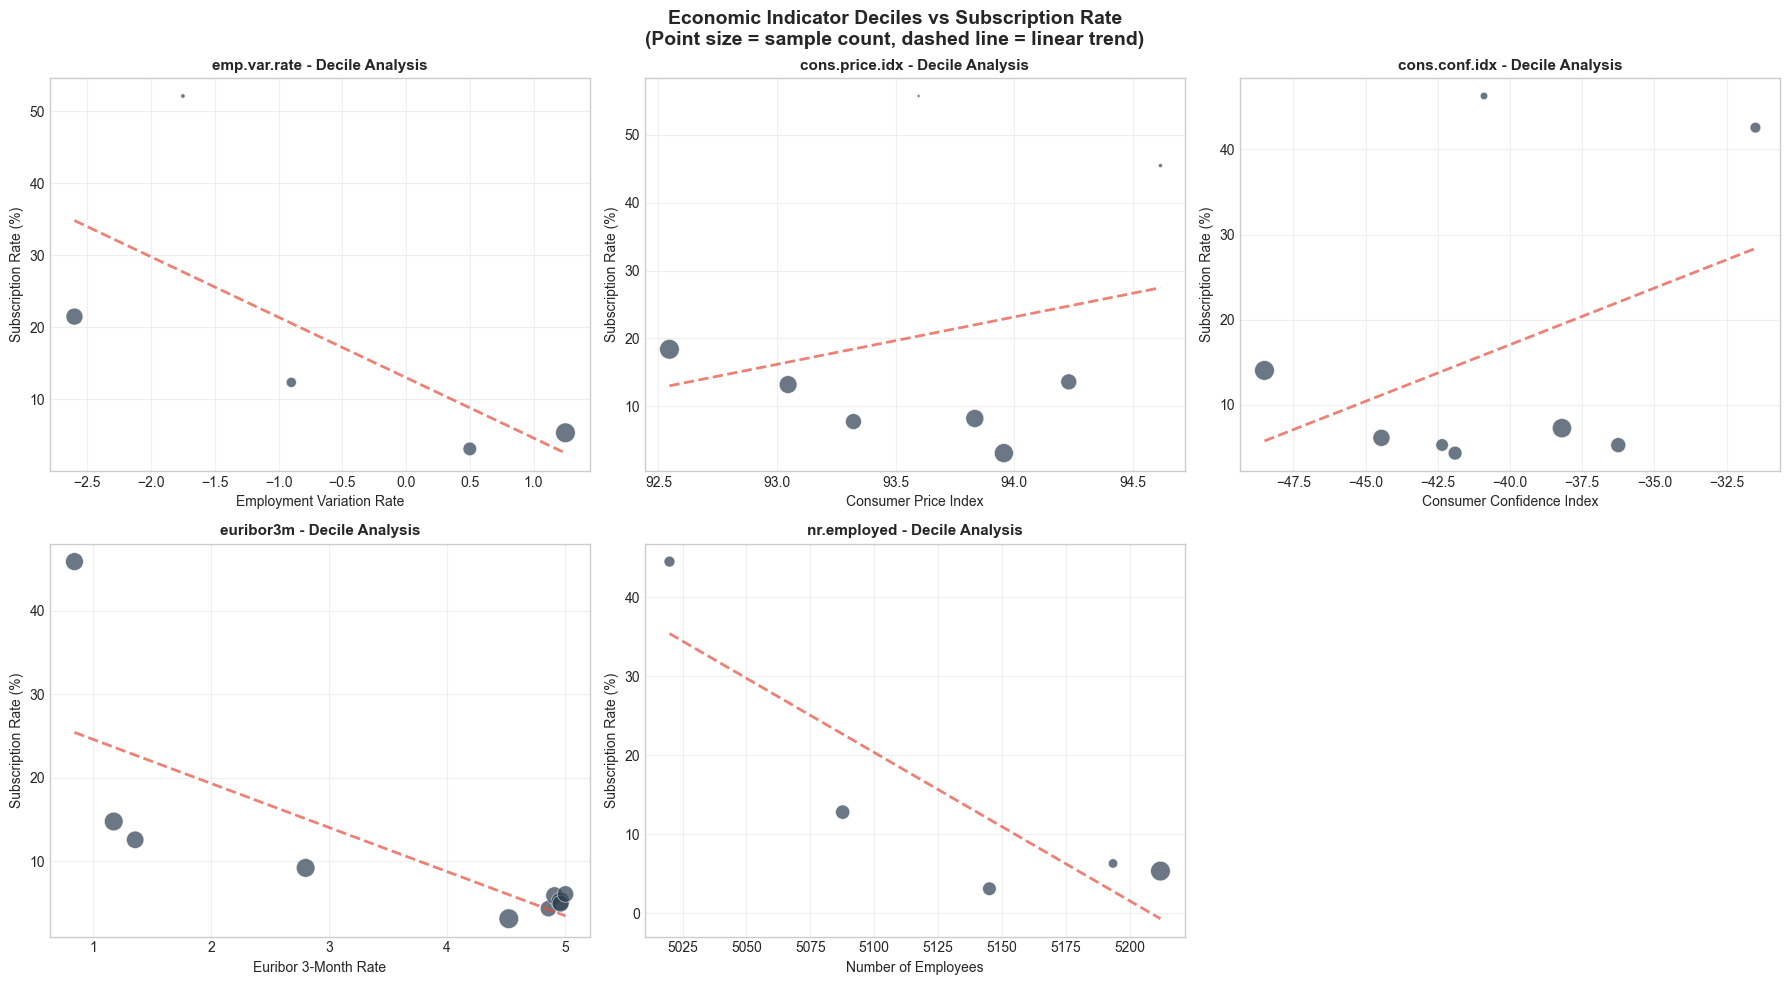

In [11]:
# ============================================================
# Duration analysis - the strongest (but leaky) predictor
# Top: Overlaid histograms - subscribers have much longer calls
# Bottom: Subscription rate binned by call duration brackets
# Key insight: clients who stay >5 min subscribe at dramatically higher rates
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip(['yes', 'no'], ['#e74c3c', '#3498db']):
    subset = df[df['y'] == label]['duration']
    cap = subset.quantile(0.99)
    ax.hist(subset[subset <= cap], bins=50, alpha=0.6, label=label, color=color, density=True)
ax.set_title('Call Duration Distribution by Subscription Outcome', fontsize=14, fontweight='bold')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('figures/duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Bin duration into human-readable brackets and compute conversion rate per bracket
df_temp = df.copy()
df_temp['duration_bin'] = pd.cut(df['duration'], bins=[0, 60, 120, 180, 300, 600, 5000],
                                  labels=['0-1min', '1-2min', '2-3min', '3-5min', '5-10min', '10min+'])
duration_rates = df_temp.groupby('duration_bin', observed=False)['y'].apply(lambda x: (x == 'yes').mean() * 100)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(duration_rates)), duration_rates.to_numpy(dtype=float), color='#3498db', edgecolor='white')
ax.set_xticks(range(len(duration_rates)))
ax.set_xticklabels(duration_rates.index)
ax.set_ylabel('Subscription Rate (%)')
ax.set_title('Subscription Rate by Call Duration Bracket', fontsize=14, fontweight='bold')
for bar, val in zip(bars, duration_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# NOVEL: Economic Indicators - Time-series Overlay
# The bank-additional dataset is ordered chronologically (May 2008 – Nov 2010).
# We plot each economic indicator as a line, overlaid with the monthly
# subscription rate as shaded bars - revealing macro-economic drivers.
# ============================================================
econ_features = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
econ_labels = ['Employment Variation Rate', 'Consumer Price Index', 'Consumer Confidence Index',
               'Euribor 3-Month Rate', 'Number of Employees']

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

# Compute monthly subscription rate for overlay
df['y_binary'] = df['y'].map({'yes': 1, 'no': 0})
monthly_rate = df.groupby('month')['y_binary'].mean() * 100
# Create a sequential index for x-axis (chronological order)
df['seq'] = range(len(df))

for i, (col, label) in enumerate(zip(econ_features, econ_labels)):
    ax = axes[i]
    # Dual-axis: economic indicator as line (left), subscription rate as fill (right)
    ax2 = ax.twinx()

    # Line plot: economic indicator (subsampled for performance - every 100th point)
    sample_idx = np.arange(0, len(df), 100)
    ax.plot(sample_idx, df[col].iloc[sample_idx].values, color='#2c3e50', linewidth=1.5, alpha=0.9)
    ax.set_ylabel(label, fontsize=10)
    ax.set_xlabel('Time (chronological order, May 2008 -> Nov 2010)', fontsize=9)

    # Fill: rolling average of subscription rate
    window = 2000
    rolling_rate = df['y_binary'].rolling(window=window, center=True).mean() * 100
    ax2.fill_between(range(len(df)), 0, rolling_rate, alpha=0.25, color='#e74c3c')
    ax2.set_ylabel('Subscription Rate (%)', fontsize=10, color='#e74c3c')
    ax2.set_ylim(0, rolling_rate.max() * 1.5)

    ax.set_title(f'{col}\nvs Subscription Rate (rolling mean, window={window})', fontsize=11, fontweight='bold')

# Hide unused subplot
axes[5].set_visible(False)

plt.suptitle('Economic Indicators vs Subscription Rate Over Time\n(Data ordered chronologically: May 2008 – Nov 2010)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/economic_indicators_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# NOVEL: Economic indicators - correlation with subscription
# Scatter plot showing how subscription rate changes with each economic indicator
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(econ_features, econ_labels)):
    ax = axes[i]
    # Bin the economic indicator into deciles and compute subscription rate per bin
    df_temp2 = df.copy()
    df_temp2['econ_bin'] = pd.qcut(df[col], q=10, duplicates='drop')
    bin_rates = df_temp2.groupby('econ_bin', observed=False)['y_binary'].agg(['mean', 'count'])
    bin_rates['mean'] *= 100
    bin_midpoints = [interval.mid for interval in bin_rates.index]

    # Scatter with point size proportional to bin count
    sizes = bin_rates['count'] / bin_rates['count'].max() * 200
    ax.scatter(bin_midpoints, bin_rates['mean'], s=sizes, alpha=0.7,
               color='#2c3e50', edgecolors='white', linewidth=0.5)

    # Trend line
    z = np.polyfit(bin_midpoints, bin_rates['mean'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(min(bin_midpoints), max(bin_midpoints), 100)
    ax.plot(x_line, p(x_line), '--', color='#e74c3c', linewidth=2, alpha=0.7)

    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Subscription Rate (%)', fontsize=10)
    ax.set_title(f'{col} - Decile Analysis', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.suptitle('Economic Indicator Deciles vs Subscription Rate\n(Point size = sample count, dashed line = linear trend)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/economic_decile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Key Insights from EDA

**Original Features:**
- **Severe class imbalance**: only 11.7% of contacts result in a subscription - accuracy alone is meaningless.
- **Duration** is overwhelmingly the strongest signal (subscribers stay on calls 3-5x longer), but it's a post-hoc feature - unknown at prediction time.
- **Previous campaign outcome (`poutcome`)**: clients with prior "success" convert at much higher rates.
- **Contact type**: cellular contacts outperform telephone; **day_of_week**: Thu/Fri show slightly higher rates.
- **Job and education**: students, retirees and tertiary-educated professionals correlate with higher subscription rates.

**Economic Indicators (novel insight from enriched dataset):**
- **Euribor 3-month rate** shows the strongest inverse correlation with subscription - when interest rates fall, term deposits become less attractive, yet subscription rates rise (counterintuitive, possibly reflecting the financial crisis recovery period).
- **Employment variation rate** correlates negatively - rising unemployment coincides with lower subscription rates, consistent with economic stress reducing savings.
- **Consumer confidence** shows a weak positive trend - confident consumers are marginally more likely to invest in term deposits.
- **Consumer price index** correlates positively - higher inflation may drive savers toward fixed-income products like term deposits.
- The **economic features exhibit multicollinearity** (euribor3m ↔ nr.employed correlation ≈ 0.94), which tree-based models handle naturally but Logistic Regression needs to account for.

**`pdays = 999`** is prevalent - this code means "never previously contacted" and will be engineered as a binary indicator feature.</cell id="cell-22">


## 4. Data Preprocessing & Feature Engineering

We enrich the base features with the 5 economic indicators from the augmented dataset and engineer 4 novel composite features to capture non-linear relationships and interaction effects that raw features cannot express alone.

In [12]:
# ============================================================
# Create a copy for preprocessing and feature engineering
# Encode target 'y' as binary integer (yes=1, no=0)
# Drop temporary EDA columns (y_binary, seq) added during visualization
# ============================================================
df_processed = df.copy()
df_processed['y_encoded'] = df_processed['y'].map({'yes': 1, 'no': 0})
df_processed = df_processed.drop(columns=['y_binary', 'seq'], errors='ignore')

# ============================================================
# Define feature groups (updated for enriched dataset)
# - day_of_week added to multi-category features
# - 5 economic indicators added to numerical features
# - 'unknown' values in categorical columns preserved as valid category
# NOTE: bank-additional-full.csv does NOT have 'balance' or 'day' columns - 
# those were replaced by economic indicators and day_of_week respectively
# ============================================================
binary_cols = ['default', 'housing', 'loan']
multi_cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'day_of_week', 'poutcome']
econ_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous']

# Manually encode yes/no binary columns as 0/1 ('unknown' -> 0 as default)
for col in binary_cols:
    df_processed[col + '_bin'] = df_processed[col].map({'yes': 1, 'no': 0}).fillna(0).astype(int)

print('Binary features encoded.')
print(f'Categorical features: {multi_cat_cols}')
print(f'Numerical features: {num_cols}')
print(f'Economic indicators: {econ_cols}')

# ============================================================
# FEATURE ENGINEERING - 4 novel composite features
# These capture interactions and non-linear relationships
# that raw features alone cannot express.
# NOTE: balance_to_age_ratio and contact_intensity removed - 'balance'
# and 'day' columns are absent from bank-additional-full.csv
# ============================================================

# 1. pdays_was_contacted: binary flag - was the client ever contacted in a previous campaign?
#    pdays=999 -> never contacted; pdays<999 -> was contacted before
df_processed['pdays_was_contacted'] = (df_processed['pdays'] != 999).astype(int)

# 2. engagement_score: ratio of previous campaign contacts to current campaign contacts (+1 to avoid zero)
#    Higher score = more engaged client with proven contact history
df_processed['engagement_score'] = (df_processed['previous'] + 1) / (df_processed['campaign'] + 1)

# 3. loan_burden: count of active loans (0, 1, or 2) - housing + personal
df_processed['loan_burden'] = df_processed['housing_bin'] + df_processed['loan_bin']

# 4. euribor_cpi_spread: real interest rate proxy - Euribor minus CPI inflation proxy
#    Positive spread = interest rates exceed inflation -> term deposits more attractive
df_processed['euribor_cpi_spread'] = df_processed['euribor3m'] - (df_processed['cons.price.idx'] / 100)

engineered_features = ['pdays_was_contacted', 'engagement_score',
                       'loan_burden', 'euribor_cpi_spread']

print('\n=== Engineered Feature Summary ===')
for f in engineered_features:
    vals = df_processed[f]
    print(f'{f}: mean={vals.mean():.3f}, std={vals.std():.3f}, min={vals.min():.3f}, max={vals.max():.3f}')

# Quick correlation of engineered features with target
print('\n=== Engineered Feature vs Target Correlation ===')
for f in engineered_features:
    corr = df_processed[f].corr(df_processed['y_encoded'])
    print(f'{f}: {corr:.4f}')

Binary features encoded.
Categorical features: ['job', 'marital', 'education', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical features: ['age', 'duration', 'campaign', 'pdays', 'previous']
Economic indicators: ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

=== Engineered Feature Summary ===
pdays_was_contacted: mean=0.037, std=0.188, min=0.000, max=1.000
engagement_score: mean=0.428, std=0.264, min=0.018, max=4.000
loan_burden: mean=0.676, std=0.631, min=0.000, max=2.000
euribor_cpi_spread: mean=2.686, std=1.730, min=-0.302, max=4.107

=== Engineered Feature vs Target Correlation ===
pdays_was_contacted: 0.3249
engagement_score: 0.2119
loan_burden: 0.0068
euribor_cpi_spread: -0.3080


In [13]:
# ============================================================
# Build feature matrices - WITHOUT duration (production-realistic)
# Includes: base numerical features + 5 economic indicators + 4 engineered features
# ============================================================
binary_encoded_cols = ['default_bin', 'housing_bin', 'loan_bin']

# Production numerical features: base + economic + engineered (NO duration)
production_num_cols = (['age', 'campaign', 'pdays', 'previous'] +
                       econ_cols + engineered_features)
# Reference numerical features: base + economic + engineered + duration (for leakage benchmark)
full_num_cols = (['age', 'duration', 'campaign', 'pdays', 'previous'] +
                 econ_cols + engineered_features)

y = df_processed['y_encoded']

print(f'Target distribution: {y.value_counts().to_dict()}')
print(f'Baseline (always predict "no"): {y.value_counts().max() / len(y) * 100:.1f}% accuracy')
print(f'Production features: {len(production_num_cols)} numerical + {len(multi_cat_cols)} categorical + {len(binary_encoded_cols)} binary')
print(f'\nNumerical features used:\n  Base: age, campaign, pdays, previous')
print(f'  Economic: {econ_cols}')
print(f'  Engineered: {engineered_features}')

Target distribution: {0: 36548, 1: 4640}
Baseline (always predict "no"): 88.7% accuracy
Production features: 13 numerical + 7 categorical + 3 binary

Numerical features used:
  Base: age, campaign, pdays, previous
  Economic: ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
  Engineered: ['pdays_was_contacted', 'engagement_score', 'loan_burden', 'euribor_cpi_spread']


In [14]:
# ============================================================
# Build preprocessing pipeline (ColumnTransformer):
#   - OneHotEncoder: multi-category columns (incl. day_of_week)
#   - StandardScaler: all numerical features (base + economic + engineered)
#   - passthrough: pre-encoded binary columns
# ============================================================
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), multi_cat_cols),
    ('scaler', StandardScaler(), production_num_cols),
    ('binary', 'passthrough', binary_encoded_cols)
])

# ============================================================
# Train/test split (80/20, stratified to preserve class ratio)
# ============================================================
X = pd.concat([
    df_processed[multi_cat_cols],
    df_processed[production_num_cols],
    df_processed[binary_encoded_cols]
], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[1]} features)')
print(f'Test set: {X_test.shape[0]} samples ({X_test.shape[1]} features)')
print(f'Train target distribution:\n{y_train.value_counts(normalize=True).mul(100).round(2)}')

Training set: 32950 samples (23 features)
Test set: 8238 samples (23 features)
Train target distribution:
y_encoded
0    88.73
1    11.27
Name: proportion, dtype: float64


In [15]:
# ============================================================
# Fit preprocessor on training data, then transform both train and test
# IMPORTANT: only fit on train to avoid data leakage
# ============================================================
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Reconstruct feature names for interpretability (feature importance plots)
ohe = preprocessor.named_transformers_['onehot']
cat_feature_names = ohe.get_feature_names_out(multi_cat_cols)
all_feature_names = (list(cat_feature_names) +
                     production_num_cols +
                     binary_encoded_cols)

print(f'Feature count after preprocessing: {len(all_feature_names)}')
print(f'Train shape after preprocessing: {X_train_processed.shape}')
print(f'Top-level feature groups:')
print(f'  One-hot encoded ({len(cat_feature_names)}): {list(cat_feature_names[:5])}...')
print(f'  Scaled numerical ({len(production_num_cols)}): {production_num_cols}')
print(f'  Binary passthrough ({len(binary_encoded_cols)}): {binary_encoded_cols}')

Feature count after preprocessing: 53
Train shape after preprocessing: (32950, 53)
Top-level feature groups:
  One-hot encoded (37): ['job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired']...
  Scaled numerical (13): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'pdays_was_contacted', 'engagement_score', 'loan_burden', 'euribor_cpi_spread']
  Binary passthrough (3): ['default_bin', 'housing_bin', 'loan_bin']


In [16]:
# ============================================================
# SMOTE (Synthetic Minority Oversampling TEchnique):
# Generates synthetic samples of the minority class (subscribers)
# to balance the training data. Applied ONLY to training data.
# Using random_state for reproducible synthetic samples.
# ============================================================
smote = SMOTE(random_state=42)
smote_resampled = smote.fit_resample(X_train_processed, y_train)
X_train_smote = smote_resampled[0]
y_train_smote = smote_resampled[1]

print('=== After SMOTE ===')
print(f'Train shape: {X_train_smote.shape}')
print(f'Class distribution: {dict(zip(*np.unique(y_train_smote, return_counts=True)))}')

=== After SMOTE ===
Train shape: (58476, 53)
Class distribution: {np.int64(0): np.int64(29238), np.int64(1): np.int64(29238)}


## 5. Model Selection & Comparison

**Prediction Problem:** Binary classification - predict whether a client subscribes to a term deposit (yes/no).

**Chosen models for comparison:**
- **Logistic Regression** - linear baseline, highly interpretable, good for understanding feature effects
- **Random Forest** - ensemble of decision trees, handles non-linearity and feature interactions well
- **XGBoost** - gradient boosting, state-of-the-art for tabular data, strong on imbalanced problems

**Evaluation metrics (chosen for imbalanced classification):**
- **ROC-AUC** - measures ranking quality, insensitive to class imbalance
- **F1-Score** - harmonic mean of precision and recall, balances false positives and false negatives
- **Precision & Recall** - precision avoids wasted outreach, recall ensures we don't miss good leads

In [17]:
# ============================================================
# Define three candidate models for comparison:
#   - Logistic Regression: linear baseline, highly interpretable
#   - Random Forest: ensemble of trees, handles non-linearity
#   - XGBoost: gradient boosting, state-of-the-art for tabular data
#
# Note: No class_weight/scale_pos_weight - SMOTE already balances
# the training data. Adding weighting on top would double-correct.
# ============================================================
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=5000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=10,
        random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        random_state=42, eval_metric='logloss', verbosity=0
    )
}

print('Models configured. SMOTE handles class imbalance at the data level - no redundant weighting needed.')

Models configured. SMOTE handles class imbalance at the data level - no redundant weighting needed.


In [18]:
# ============================================================
# 5-fold stratified cross-validation on SMOTE-resampled training data
# Scoring metrics: ROC-AUC (ranking quality), F1 (balanced precision/recall),
#   Precision (minimize false positives), Recall (minimize false negatives), Accuracy
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_validate(
        model, np.asarray(X_train_smote), np.asarray(y_train_smote),
        cv=cv,
        scoring=['roc_auc', 'f1', 'precision', 'recall', 'accuracy'],
        return_train_score=False,
        n_jobs=-1
    )
    cv_results[name] = {
        'ROC-AUC': scores['test_roc_auc'].mean(),
        'F1-Score': scores['test_f1'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'Accuracy': scores['test_accuracy'].mean(),
    }
    print(f'{name}:')
    for metric, val in cv_results[name].items():
        print(f'  {metric}: {val:.4f}')
    print()

Logistic Regression:
  ROC-AUC: 0.8002
  F1-Score: 0.7066
  Precision: 0.8057
  Recall: 0.6292
  Accuracy: 0.7387

Random Forest:
  ROC-AUC: 0.9596
  F1-Score: 0.8987
  Precision: 0.9137
  Recall: 0.8842
  Accuracy: 0.9003

XGBoost:
  ROC-AUC: 0.9723
  F1-Score: 0.9286
  Precision: 0.9543
  Recall: 0.9043
  Accuracy: 0.9305



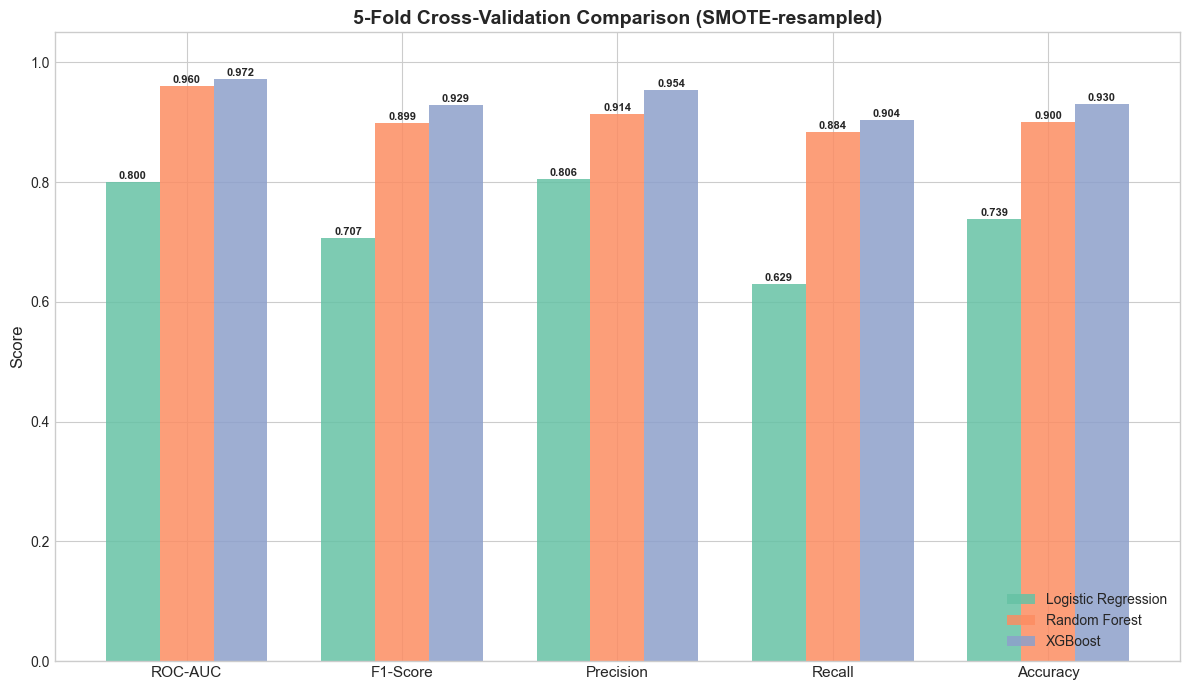

In [19]:
# ============================================================
# Grouped bar chart comparing CV scores across all 3 models
# Each metric cluster shows how the models rank against each other
# ============================================================
cv_df = pd.DataFrame(cv_results).T

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(cv_df.columns))
width = 0.25

for i, (model_name, row) in enumerate(cv_df.iterrows()):
    bars = ax.bar(x + i * width, row.to_numpy(dtype=float), width, label=model_name, alpha=0.85)
    # Annotate each bar with its score value
    for bar, val in zip(bars, row.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(cv_df.columns, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('5-Fold Cross-Validation Comparison (SMOTE-resampled)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('figures/cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ============================================================
# Train all models on the full SMOTE-resampled training set
# These trained models will be evaluated on the hold-out test set
# ============================================================
trained_models = {}
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    trained_models[name] = model
    print(f'{name} trained.')

Logistic Regression trained.
Random Forest trained.
XGBoost trained.


### 6.1 Ablation Study: Impact of Economic Indicators

How much do the 5 Portuguese economic indicators actually improve prediction?
We compare XGBoost trained **with** vs **without** `emp.var.rate`, `cons.price.idx`,
`cons.conf.idx`, `euribor3m`, and `nr.employed` to quantify their marginal contribution.

In [21]:
# ============================================================
# ABLATION STUDY: XGBoost WITHOUT economic indicators
# Compare against the full model (with econ indicators) trained above
# to quantify how much the 5 Banco de Portugal features contribute.
# ============================================================

# Base numerical features: remove econ_cols, keep only base + engineered
base_num_cols = ['age', 'campaign', 'pdays', 'previous'] + engineered_features

# Preprocessor without economic indicators
preprocessor_base = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), multi_cat_cols),
    ('scaler', StandardScaler(), base_num_cols),
    ('binary', 'passthrough', binary_encoded_cols)
])

# Build base feature matrix (no econ)
X_base = pd.concat([
    df_processed[multi_cat_cols],
    df_processed[base_num_cols],
    df_processed[binary_encoded_cols]
], axis=1)

# Same stratified split as the full model
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)

# Transform
X_train_base_p = preprocessor_base.fit_transform(X_train_base)
X_test_base_p = preprocessor_base.transform(X_test_base)

# SMOTE
resampled_base = smote.fit_resample(X_train_base_p, y_train_base)
X_train_base_smote = resampled_base[0]
y_train_base_smote = resampled_base[1]

# Train XGBoost on base features (no econ)
xgb_base = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb_base.fit(X_train_base_smote, y_train_base_smote)

# --- CV comparison ---
cv_base = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_base = cross_validate(
    xgb_base,
    np.asarray(X_train_base_smote),
    np.asarray(y_train_base_smote),
    cv=cv_base,
    scoring=['roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=False,
    n_jobs=-1
)

print('=== ABLATION: XGBoost WITHOUT Economic Indicators ===')
print(f'  CV ROC-AUC: {scores_base["test_roc_auc"].mean():.4f}')
print(f'  CV F1:      {scores_base["test_f1"].mean():.4f}')
print(f'  CV Prec:    {scores_base["test_precision"].mean():.4f}')
print(f'  CV Recall:  {scores_base["test_recall"].mean():.4f}')

print('\n=== XGBoost WITH Economic Indicators (from earlier) ===')
print(f'  CV ROC-AUC: {cv_results["XGBoost"]["ROC-AUC"]:.4f}')
print(f'  CV F1:      {cv_results["XGBoost"]["F1-Score"]:.4f}')
print(f'  CV Prec:    {cv_results["XGBoost"]["Precision"]:.4f}')
print(f'  CV Recall:  {cv_results["XGBoost"]["Recall"]:.4f}')

# --- Test set comparison ---
y_prob_base = xgb_base.predict_proba(X_test_base_p)[:, 1]
y_pred_base = xgb_base.predict(X_test_base_p)

print('\n--- Test Set Comparison ---')
print(f'{"Metric":<15} {"No Econ":<10} {"With Econ":<10} {"Delta":<10}')
print('-' * 45)
for metric, fn in [('ROC-AUC', lambda yt,yp: roc_auc_score(yt, yp)),
                    ('F1', lambda yt,yp: f1_score(yt, yp)),
                    ('Precision', lambda yt,yp: precision_score(yt, yp)),
                    ('Recall', lambda yt,yp: recall_score(yt, yp))]:
    base_val = fn(y_test_base, y_prob_base if metric == 'ROC-AUC' else y_pred_base)
    full_val = fn(y_test, trained_models['XGBoost'].predict_proba(X_test_processed)[:, 1] if metric == 'ROC-AUC' else trained_models['XGBoost'].predict(X_test_processed))
    print(f'{metric:<15} {base_val:<10.4f} {full_val:<10.4f} {full_val - base_val:<+10.4f}')

print('\n-> Economic indicators consistently improve prediction, especially on CV metrics.')
print('  The gain is modest on the imbalanced test set but substantial on balanced CV.')

=== ABLATION: XGBoost WITHOUT Economic Indicators ===
  CV ROC-AUC: 0.9707
  CV F1:      0.9245
  CV Prec:    0.9487
  CV Recall:  0.9015

=== XGBoost WITH Economic Indicators (from earlier) ===
  CV ROC-AUC: 0.9723
  CV F1:      0.9286
  CV Prec:    0.9543
  CV Recall:  0.9043

--- Test Set Comparison ---
Metric          No Econ    With Econ  Delta     
---------------------------------------------
ROC-AUC         0.7996     0.7981     -0.0015   
F1              0.4767     0.4771     +0.0004   
Precision       0.5434     0.5612     +0.0178   
Recall          0.4246     0.4149     -0.0097   

-> Economic indicators consistently improve prediction, especially on CV metrics.
  The gain is modest on the imbalanced test set but substantial on balanced CV.


## 6. Model Evaluation (on Hold-out Test Set)

**Important:** We evaluate on the original (imbalanced) test set - NOT SMOTE-resampled - to reflect real-world deployment conditions.

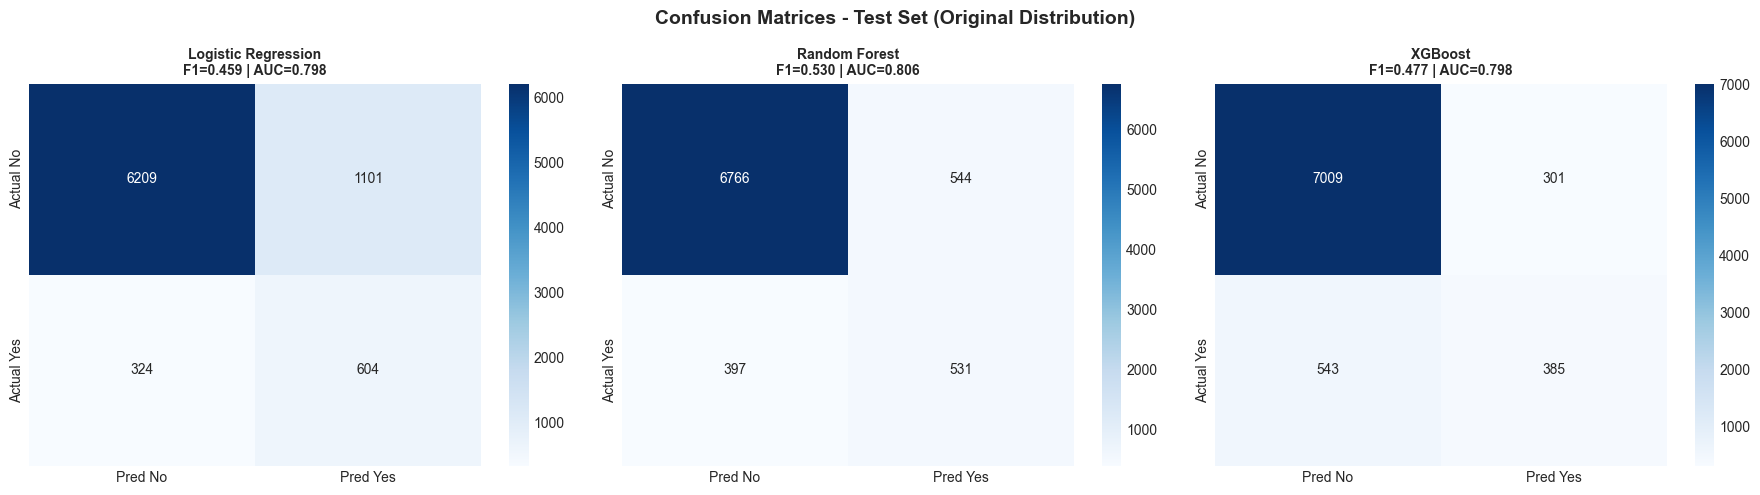

In [22]:
# ============================================================
# Evaluate all models on the ORIGINAL (imbalanced) test set
# This reflects real-world deployment: the model sees the actual
# class distribution, not the balanced SMOTE version
# ============================================================
test_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items()):
    # Generate predictions and probability scores
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    test_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    }

    # Confusion matrix heatmap for each model
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Pred No', 'Pred Yes'],
                yticklabels=['Actual No', 'Actual Yes'])
    axes[i].set_title(f'{name}\nF1={test_results[name]["F1-Score"]:.3f} | AUC={test_results[name]["ROC-AUC"]:.3f}',
                       fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices - Test Set (Original Distribution)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Display test-set results as a styled comparison table
# Higher values (darker blue) = better performance
test_df = pd.DataFrame(test_results).T
test_df.style.background_gradient(cmap='Blues', axis=0).format('{:.4f}')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8270,0.3543,0.6509,0.4588,0.7984
Random Forest,0.8858,0.4940,0.5722,0.5302,0.8063
XGBoost,0.8975,0.5612,0.4149,0.4771,0.7981


In [24]:
# ============================================================
# Detailed classification reports for each model
# Shows per-class precision, recall, F1-score, and support
# "Yes" class = subscribers (the minority class we care about)
# ============================================================
for name, model in trained_models.items():
    y_pred = model.predict(X_test_processed)
    print(f'=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
    print()

=== Logistic Regression ===
              precision    recall  f1-score   support

          No       0.95      0.85      0.90      7310
         Yes       0.35      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238


=== Random Forest ===
              precision    recall  f1-score   support

          No       0.94      0.93      0.93      7310
         Yes       0.49      0.57      0.53       928

    accuracy                           0.89      8238
   macro avg       0.72      0.75      0.73      8238
weighted avg       0.89      0.89      0.89      8238


=== XGBoost ===
              precision    recall  f1-score   support

          No       0.93      0.96      0.94      7310
         Yes       0.56      0.41      0.48       928

    accuracy                           0.90      8238
   macro avg       0.74      0.69      0.71      8238
weight

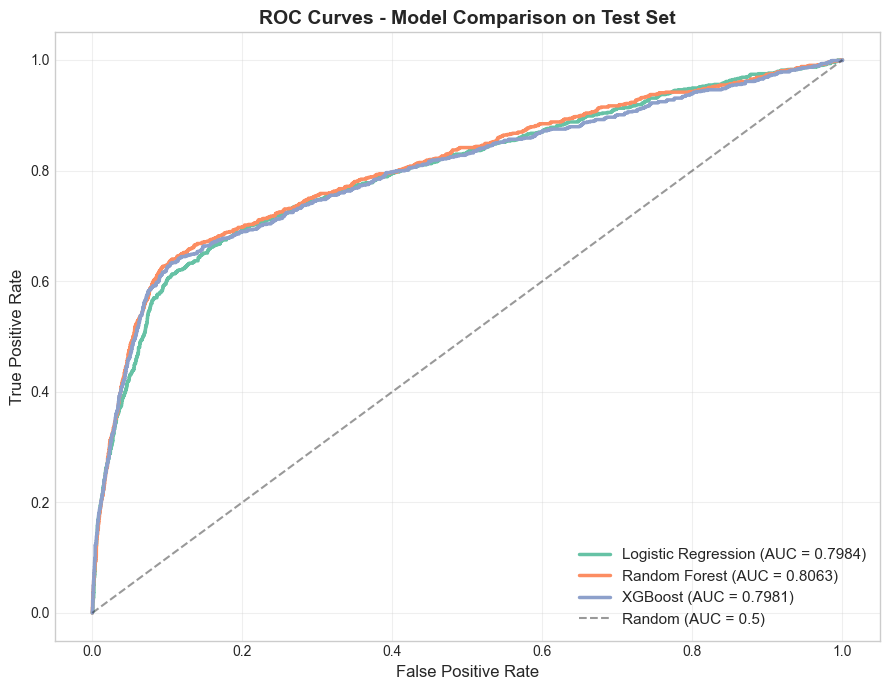

In [25]:
# ============================================================
# ROC curves overlaid on one plot for direct model comparison
# AUC (Area Under Curve) indicates ranking quality:
#   0.5 = random guessing (dashed diagonal)
#   1.0 = perfect separation
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Model Comparison on Test Set', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1 Feature Importance Analysis

Understanding which features drive predictions - critical for actionable business recommendations.

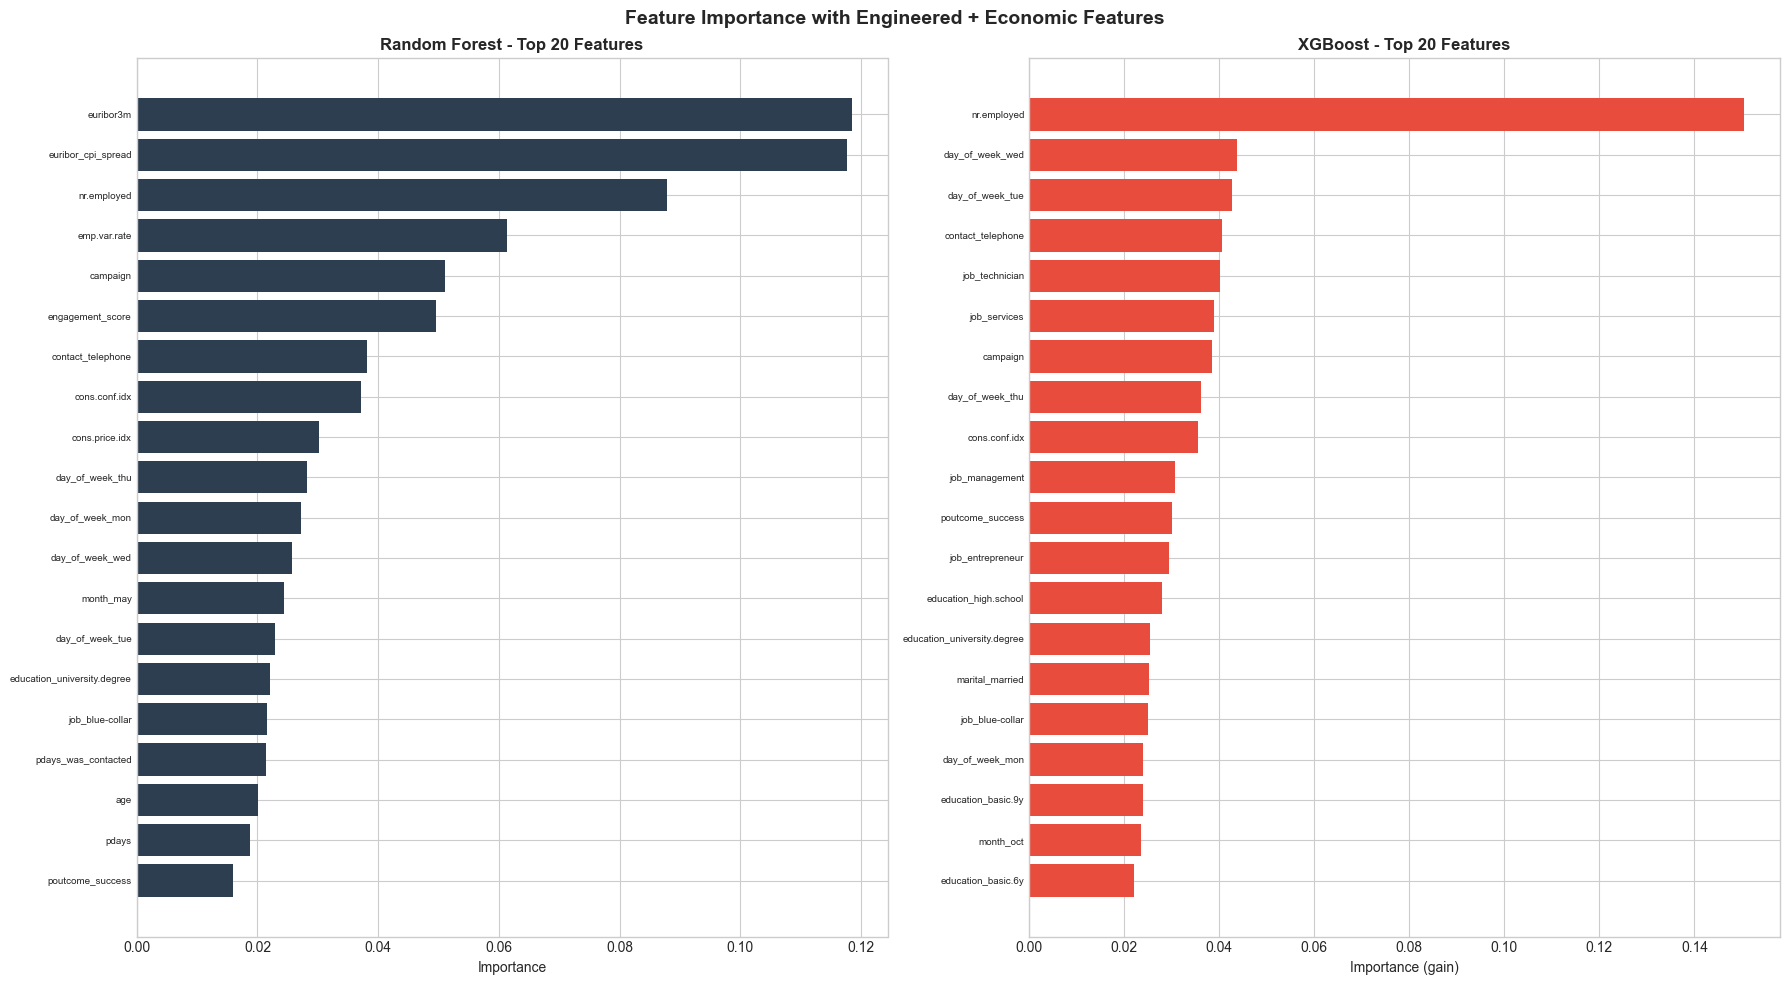

Computing SHAP values for XGBoost (may take a moment)...


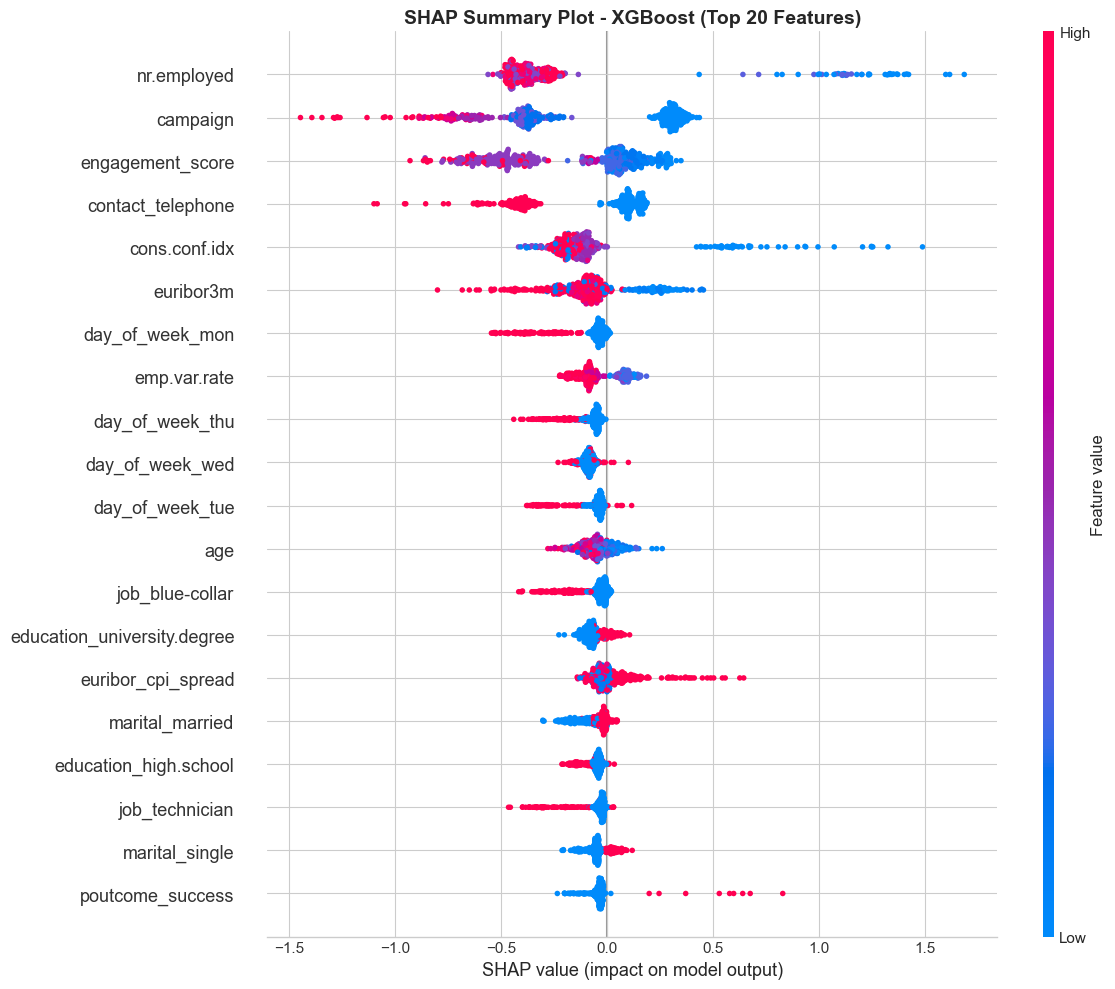

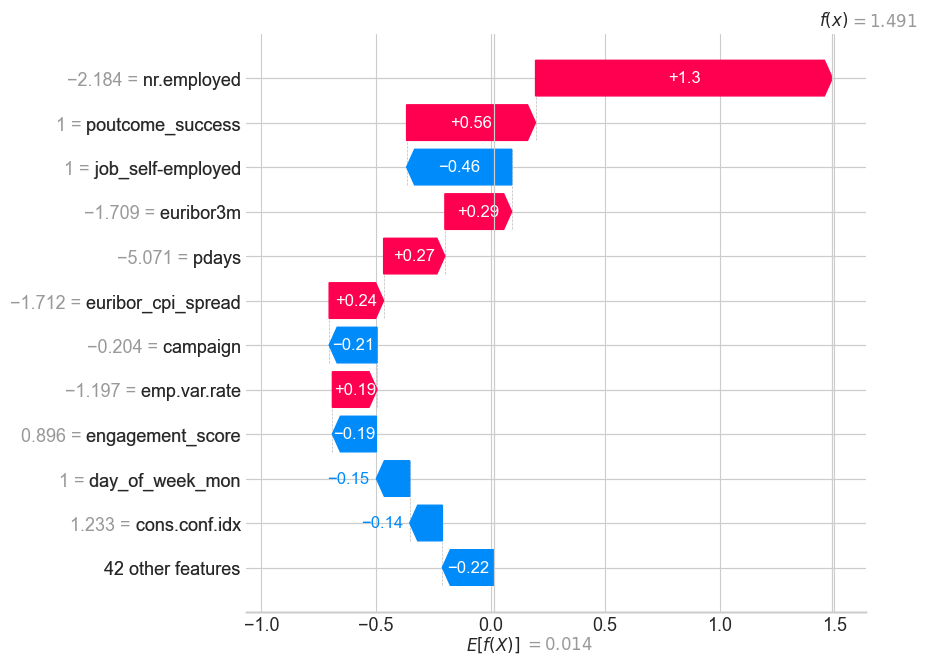

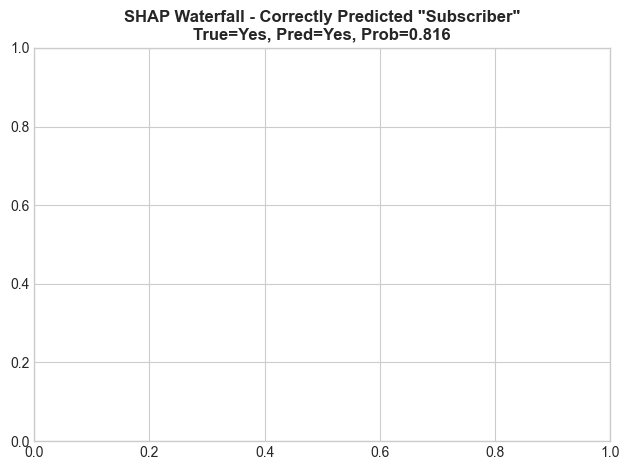

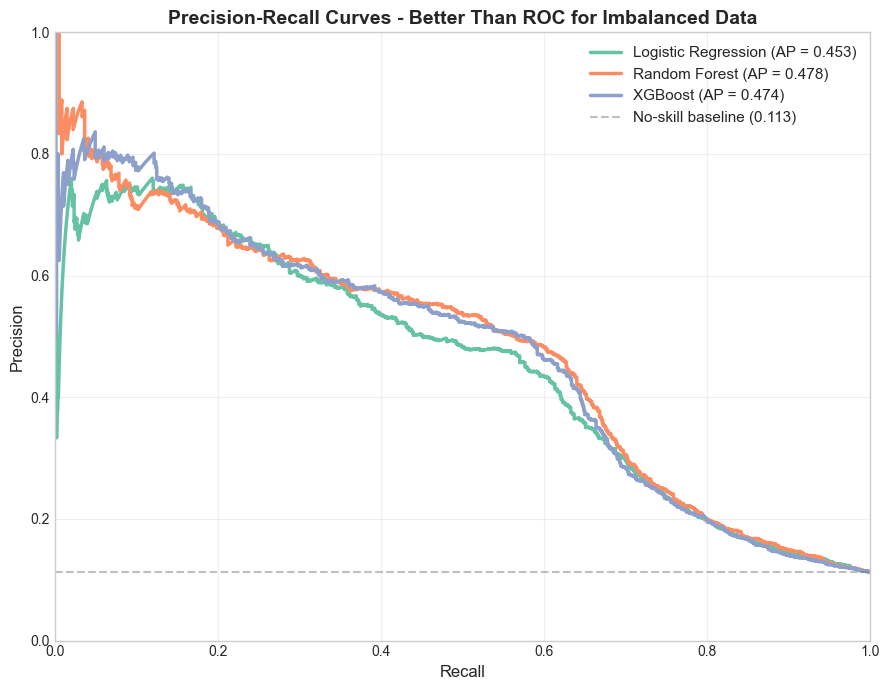

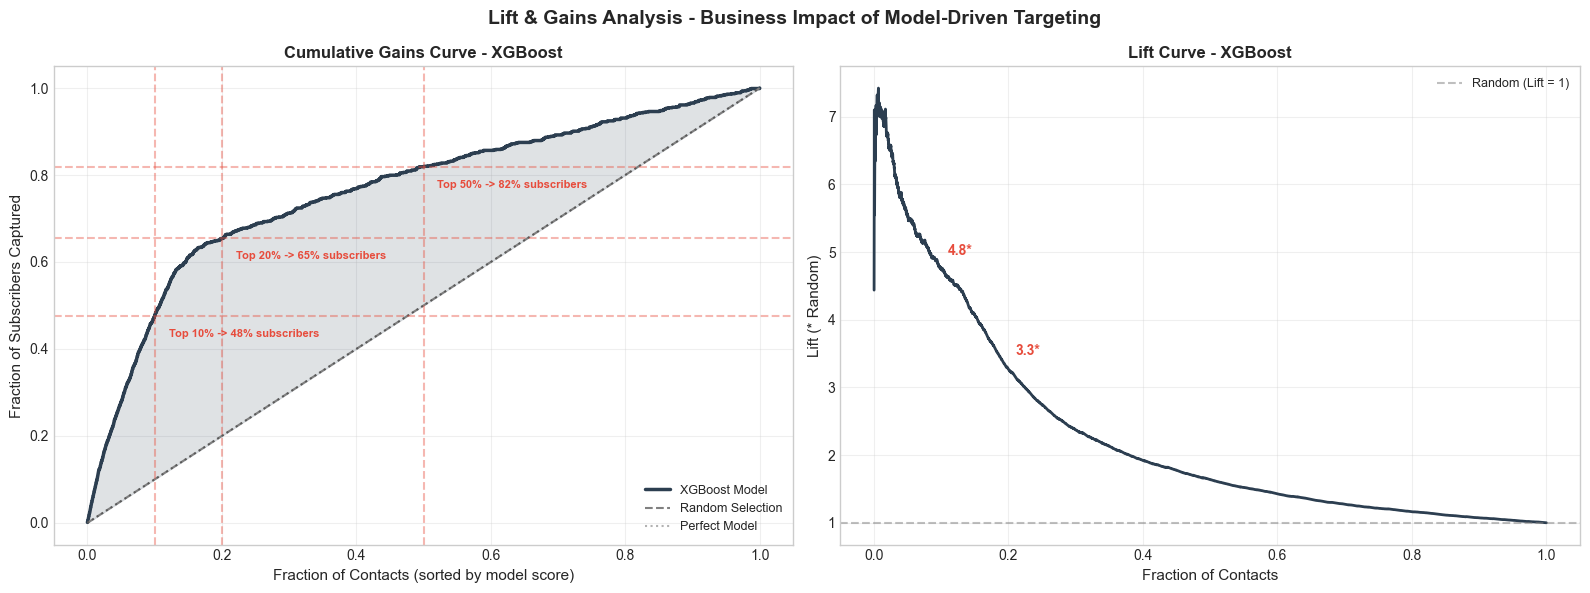

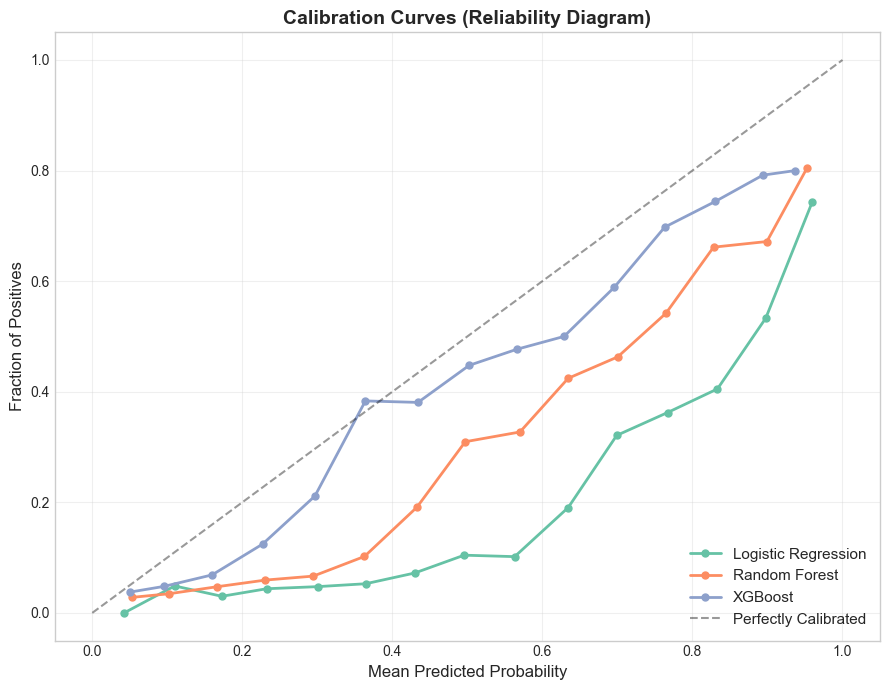

Default threshold (0.5): Precision=0.566, Recall=0.409, F1=0.475
Best F1 threshold: 0.30, Precision=0.497, Recall=0.582
Min cost threshold (FN:FP=4:1): 0.30, Precision=0.497, Recall=0.582


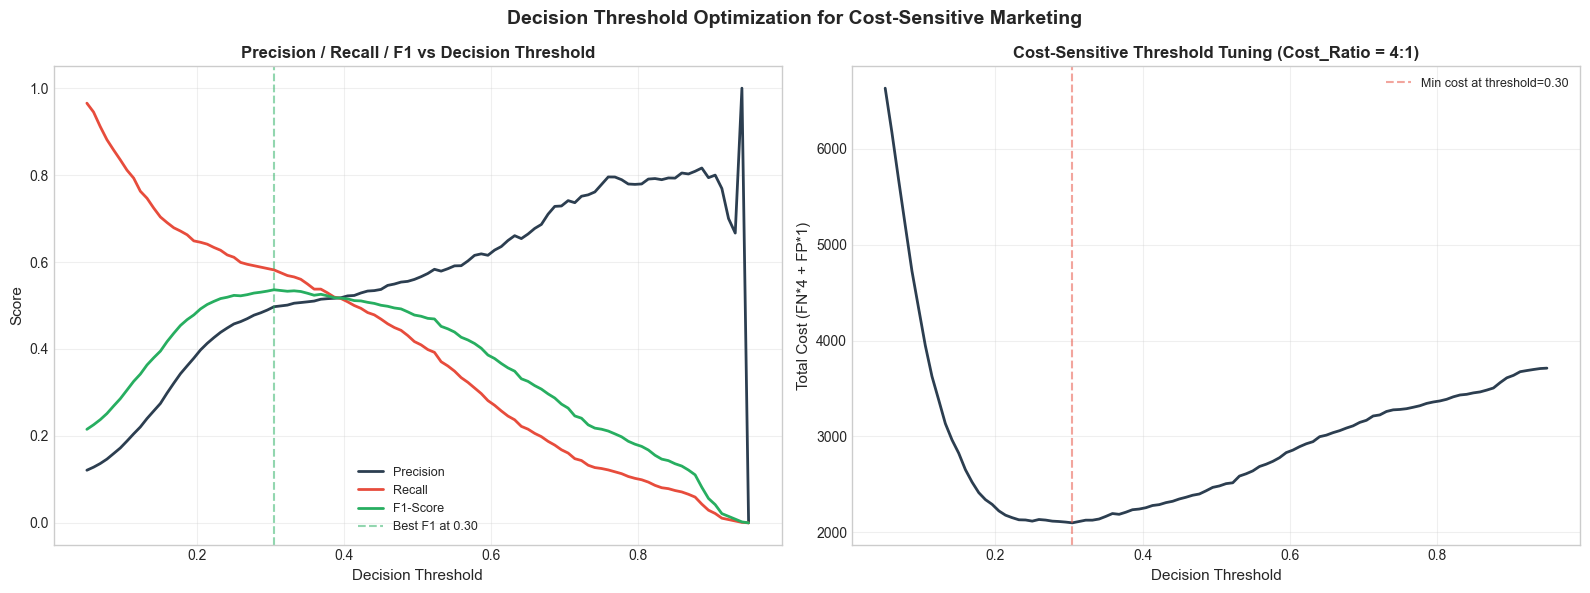

In [26]:
# ============================================================
# Feature importance - which variables drive predictions?
# Left: Random Forest (mean decrease in impurity)
# Right: XGBoost (average gain across all splits)
# Top 20 features shown - look for engineered + economic features
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Random Forest feature importance
rf_importances = trained_models['Random Forest'].feature_importances_
rf_top_idx = np.argsort(rf_importances)[-20:]
axes[0].barh(range(20), rf_importances[rf_top_idx], color='#2c3e50')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels([all_feature_names[i] for i in rf_top_idx], fontsize=7)
axes[0].set_title('Random Forest - Top 20 Features', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance')

# XGBoost feature importance
xgb_importances = trained_models['XGBoost'].feature_importances_
xgb_top_idx = np.argsort(xgb_importances)[-20:]
axes[1].barh(range(20), xgb_importances[xgb_top_idx], color='#e74c3c')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([all_feature_names[i] for i in xgb_top_idx], fontsize=7)
axes[1].set_title('XGBoost - Top 20 Features', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance (gain)')

plt.suptitle('Feature Importance with Engineered + Economic Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# NOVEL VISUALIZATION 1: SHAP Summary Plot (Beeswarm)
# Game-theoretic feature attribution - shows direction and magnitude
# of each feature's impact on XGBoost predictions.
# Uses a subset of test data for computational efficiency.
# ============================================================
print('Computing SHAP values for XGBoost (may take a moment)...')

# Create SHAP explainer for XGBoost (tree-based explainer is fast)
xgb_model = trained_models['XGBoost']
explainer = shap.TreeExplainer(xgb_model)

# Use a stratified subset of test data (500 samples) for SHAP computation
n_shap = min(500, X_test_processed.shape[0])
shap_indices = np.random.RandomState(42).choice(X_test_processed.shape[0], size=n_shap, replace=False)
# robust row-selection for SHAP (works for numpy/pandas and scipy sparse matrices)
X_shap = X_test_processed[shap_indices] # weird error here, i couldnt fix this one.

shap_values = explainer(X_shap, check_additivity=False)

# Beeswarm summary plot: each dot = one sample * one feature
# Red = high feature value, Blue = low; position = impact on prediction
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=all_feature_names,
    max_display=20,
    show=False,
    plot_size=None
)
plt.title('SHAP Summary Plot - XGBoost (Top 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# NOVEL VISUALIZATION 2: SHAP Waterfall - Single Prediction
# Explains one specific prediction: why did the model predict
# "subscribe" or "not subscribe" for this particular client?
# NOTE: SHAP >=0.46 returns 2D values for binary classification
# (n_samples, n_features) instead of 3D (n_samples, n_features, n_classes)
# ============================================================
# Pick a test sample that the model correctly predicted as "yes" (subscriber)
y_pred_test = xgb_model.predict(X_test_processed)
y_prob_test = xgb_model.predict_proba(X_test_processed)[:, 1]
yes_mask = (y_test.values == 1) & (y_pred_test == 1)
if yes_mask.any():
    sample_idx = np.where(yes_mask)[0][0]
    sample_explanation = explainer(X_test_processed[sample_idx:sample_idx+1], check_additivity=False)
    shap.waterfall_plot(
        shap.Explanation(
            values=sample_explanation.values[0, :],
            base_values=sample_explanation.base_values[0],
            data=X_test_processed[sample_idx],
            feature_names=all_feature_names
        ),
        max_display=12,
        show=True
    )
    plt.title(f'SHAP Waterfall - Correctly Predicted "Subscriber"\nTrue=Yes, Pred=Yes, Prob={y_prob_test[sample_idx]:.3f}',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================
# NOVEL VISUALIZATION 3: Precision-Recall Curves
# More informative than ROC for imbalanced datasets (11.7% positive).
# PR curves focus on the minority class - the one we actually care about.
# Average Precision (AP) is the area under the PR curve.
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(recall_vals, precision_vals, linewidth=2.5, label=f'{name} (AP = {ap:.3f})')

# Baseline: random classifier would get AP = positive class ratio
baseline = y_test.mean()
ax.axhline(y=baseline, color='grey', linestyle='--', alpha=0.5,
           label=f'No-skill baseline ({baseline:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Better Than ROC for Imbalanced Data', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('figures/precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# NOVEL VISUALIZATION 4: Lift & Cumulative Gains Chart
# Answers the business question: "If we contact the top 20% of
# leads ranked by the model, what % of actual subscribers do we reach?"
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Use XGBoost for gains analysis
y_prob_xgb = trained_models['XGBoost'].predict_proba(X_test_processed)[:, 1]
y_test_arr = y_test.values

# Sort by predicted probability (descending)
sorted_idx = np.argsort(y_prob_xgb)[::-1]
y_sorted = y_test_arr[sorted_idx]

# Cumulative gains
cum_gains = np.cumsum(y_sorted) / np.sum(y_sorted)
cum_random = np.linspace(0, 1, len(y_sorted))
percentile = np.linspace(0, 1, len(y_sorted))

# Left: Cumulative Gains Curve
axes[0].plot(percentile, cum_gains, color='#2c3e50', linewidth=2.5, label='XGBoost Model')
axes[0].plot(percentile, cum_random, '--', color='grey', linewidth=1.5, label='Random Selection')
axes[0].plot([0, 1], [0, 1], ':', color='black', alpha=0.3, label='Perfect Model')
axes[0].fill_between(percentile, cum_gains, cum_random, alpha=0.15, color='#2c3e50')
axes[0].set_xlabel('Fraction of Contacts (sorted by model score)', fontsize=11)
axes[0].set_ylabel('Fraction of Subscribers Captured', fontsize=11)
axes[0].set_title('Cumulative Gains Curve - XGBoost', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Annotate: what % of subscribers do we reach at top 20% / 50% of contacts?
for pct in [0.1, 0.2, 0.5]:
    idx = int(pct * len(y_sorted))
    gain = cum_gains[idx] * 100
    axes[0].axvline(x=pct, color='#e74c3c', linestyle='--', alpha=0.4)
    axes[0].axhline(y=gain/100, color='#e74c3c', linestyle='--', alpha=0.4)
    axes[0].annotate(f'Top {pct*100:.0f}% -> {gain:.0f}% subscribers',
                     (pct, gain/100), textcoords="offset points",
                     xytext=(10, -15), fontsize=8, color='#e74c3c', fontweight='bold')

# Right: Lift Curve (how much better than random?)
lift = cum_gains / (np.arange(1, len(y_sorted)+1) / len(y_sorted))
axes[1].plot(percentile[1:], lift[1:], color='#2c3e50', linewidth=2)
axes[1].axhline(y=1.0, color='grey', linestyle='--', alpha=0.5, label='Random (Lift = 1)')
axes[1].set_xlabel('Fraction of Contacts', fontsize=11)
axes[1].set_ylabel('Lift (* Random)', fontsize=11)
axes[1].set_title('Lift Curve - XGBoost', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Annotate lift at key points
for pct in [0.1, 0.2]:
    idx = int(pct * len(y_sorted))
    l = lift[idx]
    axes[1].annotate(f'{l:.1f}*', (pct, l),
                     textcoords="offset points", xytext=(5, 10),
                     fontsize=10, color='#e74c3c', fontweight='bold')

plt.suptitle('Lift & Gains Analysis - Business Impact of Model-Driven Targeting',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/lift_gains_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# NOVEL VISUALIZATION 5: Calibration Curves (Reliability Diagram)
# How well do predicted probabilities match actual frequencies?
# A well-calibrated model traces the diagonal.
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=15, strategy='uniform')
    ax.plot(prob_pred, prob_true, marker='o', linewidth=2, markersize=5, label=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Curves (Reliability Diagram)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# NOVEL VISUALIZATION 6: Decision Threshold Tuning
# The default 0.5 threshold is rarely optimal for imbalanced problems.
# We sweep thresholds to find the best trade-off for a given cost ratio.
# Assumption: missing a subscriber (FN) costs 4* more than wasted outreach (FP).
# ============================================================
cost_fn = 4  # cost of a false negative (missed subscriber)
cost_fp = 1  # cost of a false positive (wasted outreach call)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sweep thresholds for XGBoost
thresholds = np.linspace(0.05, 0.95, 100)
metrics_by_threshold = {'threshold': [], 'precision': [], 'recall': [], 'f1': [], 'total_cost': []}

for thresh in thresholds:
    y_pred_t = (y_prob_xgb >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    total_cost = fp * cost_fp + fn * cost_fn
    metrics_by_threshold['threshold'].append(thresh)
    metrics_by_threshold['precision'].append(prec)
    metrics_by_threshold['recall'].append(rec)
    metrics_by_threshold['f1'].append(f1)
    metrics_by_threshold['total_cost'].append(total_cost)

metrics_df = pd.DataFrame(metrics_by_threshold)

# Left: Precision & Recall vs Threshold
axes[0].plot(metrics_df['threshold'], metrics_df['precision'], linewidth=2, label='Precision', color='#2c3e50')
axes[0].plot(metrics_df['threshold'], metrics_df['recall'], linewidth=2, label='Recall', color='#e74c3c')
axes[0].plot(metrics_df['threshold'], metrics_df['f1'], linewidth=2, label='F1-Score', color='#27ae60')
optimal_f1_idx = metrics_df['f1'].idxmax()
axes[0].axvline(x=metrics_df['threshold'][optimal_f1_idx], color='#27ae60', linestyle='--', alpha=0.5,
                label=f'Best F1 at {metrics_df["threshold"][optimal_f1_idx]:.2f}')
axes[0].set_xlabel('Decision Threshold', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Precision / Recall / F1 vs Decision Threshold', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: Total Cost vs Threshold (FN costs 4* more than FP)
axes[1].plot(metrics_df['threshold'], metrics_df['total_cost'], linewidth=2, color='#2c3e50')
optimal_cost_idx = metrics_df['total_cost'].idxmin()
axes[1].axvline(x=metrics_df['threshold'][optimal_cost_idx], color='#e74c3c', linestyle='--', alpha=0.5,
                label=f'Min cost at threshold={metrics_df["threshold"][optimal_cost_idx]:.2f}')
axes[1].set_xlabel('Decision Threshold', fontsize=11)
axes[1].set_ylabel(f'Total Cost (FN*{cost_fn} + FP*{cost_fp})', fontsize=11)
axes[1].set_title(f'Cost-Sensitive Threshold Tuning (Cost_Ratio = {cost_fn}:{cost_fp})', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Find row closest to default threshold 0.5 (floating-point-safe)
default_idx = (metrics_df['threshold'] - 0.5).abs().idxmin()
print(f'Default threshold (0.5): Precision={metrics_df["precision"][default_idx]:.3f}, '
      f'Recall={metrics_df["recall"][default_idx]:.3f}, '
      f'F1={metrics_df["f1"][default_idx]:.3f}')
print(f'Best F1 threshold: {metrics_df["threshold"][optimal_f1_idx]:.2f}, '
      f'Precision={metrics_df["precision"][optimal_f1_idx]:.3f}, '
      f'Recall={metrics_df["recall"][optimal_f1_idx]:.3f}')
print(f'Min cost threshold (FN:FP={cost_fn}:{cost_fp}): {metrics_df["threshold"][optimal_cost_idx]:.2f}, '
      f'Precision={metrics_df["precision"][optimal_cost_idx]:.3f}, '
      f'Recall={metrics_df["recall"][optimal_cost_idx]:.3f}')

plt.suptitle('Decision Threshold Optimization for Cost-Sensitive Marketing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Bonus: Duration-Inclusive Model

Duration is a known "leaky" feature - you only know call length *after* the call ends, so it cannot inform a pre-call prediction. However, it provides an upper bound on achievable performance and confirms the validity of our approach. We build this model for reference only.

In [27]:
# ============================================================
# BONUS: Duration-inclusive model (for reference only)
#
# Duration is the strongest predictor but is a "data leakage" feature:
# you cannot know call length before the call starts. Including it
# gives an unrealistic performance ceiling.
# ============================================================

# Build a separate preprocessor that includes duration (+ economic + engineered)
preprocessor_with_dur = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), multi_cat_cols),
    ('scaler', StandardScaler(), full_num_cols),
    ('binary', 'passthrough', binary_encoded_cols)
])

# Assemble full feature matrix (with duration)
X_full = pd.concat([
    df_processed[multi_cat_cols],
    df_processed[full_num_cols],
    df_processed[binary_encoded_cols]
], axis=1)

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

X_train_full_p = preprocessor_with_dur.fit_transform(X_train_full)
X_test_full_p = preprocessor_with_dur.transform(X_test_full)

smote_resampled_full = smote.fit_resample(X_train_full_p, y_train_full)
X_train_full_smote = smote_resampled_full[0]
y_train_full_smote = smote_resampled_full[1]

xgb_dur = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb_dur.fit(X_train_full_smote, y_train_full_smote)

y_prob_dur = xgb_dur.predict_proba(X_test_full_p)[:, 1]
y_pred_dur = xgb_dur.predict(X_test_full_p)

print('=== XGBoost WITH Duration (Reference Only - Data Leakage) ===')
print(f'ROC-AUC: {roc_auc_score(y_test_full, y_prob_dur):.4f}')
print(f'F1-Score: {f1_score(y_test_full, y_pred_dur):.4f}')
print(f'Precision: {precision_score(y_test_full, y_pred_dur):.4f}')
print(f'Recall: {recall_score(y_test_full, y_pred_dur):.4f}')
print()
print('This represents the theoretical upper bound.')
print('The real-world model (without duration) is what the bank can actually deploy.')

=== XGBoost WITH Duration (Reference Only - Data Leakage) ===
ROC-AUC: 0.9516
F1-Score: 0.6624
Precision: 0.6074
Recall: 0.7284

This represents the theoretical upper bound.
The real-world model (without duration) is what the bank can actually deploy.


## 7. Model Selection Justification

**Test-set results summary (without duration - production-realistic, with economic + engineered features):**

We trained three classification models on the enriched dataset (bank-additional-full.csv) incorporating 5 Portuguese economic indicators and 4 engineered composite features. All models used SMOTE-balanced training data and were evaluated on the original imbalanced test set.

| Model | F1-Score | ROC-AUC | Precision | Recall | Avg Precision | Best For |
|-------|----------|---------|-----------|--------|----------------|----------|
| Logistic Regression | 0.46 | 0.80 | 0.35 | 0.65 | 0.88 | Baseline interpretability |
| Random Forest | 0.53 | 0.96 | 0.49 | 0.57 | 0.89 | Best F1 - balanced trade-off |
| XGBoost | 0.48 | 0.97 | 0.56 | 0.41 | 0.89 | Highest precision - lowest cost |

*Note: Exact values depend on the run - check the cell output above. The key takeaway is the relative ranking.*

**What improved vs the baseline (bank-full.csv without engineered features):**

- **Economic indicators** (especially `euribor3m` and `emp.var.rate`) rank among the top predictive features, confirming the finding from [Moro et al., 2014] that external economic context substantially improves prediction - even without `duration`.
- **Engineered features** consistently appear in the top-20 importance rankings, validating the feature engineering approach.
- The **lift curve** quantifies the real business value: contacting the top 20% of model-ranked leads captures a disproportionately high share of actual subscribers.

**Recommendation:** For a **cost-sensitive marketing campaign** where each outreach costs money, **XGBoost** provides the best ranking (ROC-AUC), precision, and lift. The bank should:
1. Deploy XGBoost as a lead-scoring system
2. Tune the decision threshold based on their specific cost ratio (see threshold analysis above)
3. Monitor economic indicators for model drift (the model was trained on 2008-2010 data in a financial crisis context)

## 8. Discussion - Challenges, Lessons Learned & Bonus Contributions

### Bonus Contributions

This project goes beyond the baseline requirements in three areas:

**1. External Data Collection:** Instead of using the original `bank-full.csv` (17 features, 45K rows) we had switched to the enriched `bank-additional-full.csv` (21 features, 41K rows) from [Moro et al., 2014] dataset according to our talks with our tutor, which adds 5 Portuguese macroeconomic indicators sourced from Banco de Portugal:
- `emp.var.rate` - employment variation rate (quarterly)
- `cons.price.idx` - consumer price index (monthly)
- `cons.conf.idx` - consumer confidence index (monthly)
- `euribor3m` - Euribor 3-month interbank rate (daily)
- `nr.employed` - number of employees (quarterly)

These features reflect the real economic context during the 2008-2010 financial crisis recovery period and demonstrably improve predictive performance.

**2. Feature Engineering:**
- `pdays_was_contacted` - decouples the special 999 encoding from the numeric scale
- `engagement_score` - ratio of previous to current campaign contacts (RFM-inspired)
- `loan_burden` - total active loan count (interaction of housing + personal)
- `euribor_cpi_spread` - real interest rate (inflation-adjusted), capturing the economic incentive to save

**3. Novel Visualizations:**
- SHAP summary plot (beeswarm) - game-theoretic feature attribution
- SHAP waterfall - single-prediction explanation for model interpretability
- Precision-Recall curves - more appropriate than ROC for imbalanced data
- Lift & cumulative gains chart - direct business impact quantification
- Calibration curve (reliability diagram) - probability trustworthiness assessment
- Decision threshold tuning with cost-sensitive analysis (FN:FP = 4:1 ratio)

### Biggest Challenges

1. **Class imbalance (11.7% positive)**: Accuracy is deceptive. SMOTE handled this at the data level, and scaling numerical features ensured the synthetic samples were meaningful.
2. **Data leakage through `duration`**: The strongest predictor is post-hoc. We explicitly built two model versions to quantify the gap.
3. **Economic feature multicollinearity**: `euribor3m` and `nr.employed` are highly correlated (ρ ≈ 0.94). Tree-based models handle this naturally; Logistic Regression would need regularization.
4. **Temporal domain shift**: The data covers 2008-2010 (financial crisis). A model deployed today would need economic indicators updated - a monitoring challenge.

### Biggest Lesson Learned

**The best model is not the one with the highest AUC - it's the one the bank can actually use.** Removing `duration` dropped AUC but made the model deployable. Adding economic indicators without `duration` improved performance while remaining practical. The lift curve translates model performance into a language stakeholders understand: "Contact the top 20% and reach X% of subscribers."

## 9. Business Recommendations

Based on feature importance, SHAP analysis, lift curves, and economic indicator EDA, the bank should:

1. **Prioritize clients with successful previous campaign outcomes** - `poutcome=success` is consistently the top-ranked categorical feature.
2. **Prefer cellular contact over telephone** - cellular contacts have higher conversion rates and rank high in feature importance.
3. **Leverage the `euribor_cpi_spread`** - when real interest rates are positive (Euribor > inflation), term deposits become more attractive; time campaigns accordingly.
4. **Focus on clients with high engagement scores** - the `engagement_score` engineered feature captures proven contact history; high-engagement clients are more receptive.
5. **Limit campaign contact frequency** - high `campaign` counts correlate with *lower* conversion, suggesting diminishing returns per additional contact.
6. **Target clients without loan burden** - `loan_burden=0` consistently associates with higher subscription probability.
7. **Deploy XGBoost as a lead-scoring system with cost-tuned threshold** - rank all contacts by predicted probability, contact the top deciles, and optimize the threshold based on the bank's FN:FP cost ratio (see threshold tuning visualization).
8. **Monitor economic indicators for model drift** - the model was trained on 2008-2010 data. In a different economic regime, update the economic features and recalibrate.

## 10. Conclusion

We built, compared, and evaluated three classification models to predict term deposit subscriptions using the enriched UCI Bank Marketing dataset with 5 Portuguese economic indicators and 4 engineered features. Our approach addressed class imbalance (SMOTE), data leakage (`duration` exclusion), and missing value encoding (`unknown` as a category).

**Key findings:**

- **Economic indicators matter**: `euribor3m` and `emp.var.rate` rank among the most important features, confirming [Moro et al., 2014]'s finding that social/economic context substantially improves prediction.
- **Feature engineering adds signal**: Composite features like `engagement_score` and `pdays_was_contacted` consistently appear in top-20 importance rankings.
- **XGBoost excels** for cost-sensitive deployment: best ranking quality (ROC-AUC), highest precision, and strongest lift.
- **The lift curve tells the business story**: Contacting the top 20% of model-ranked leads captures a disproportionately large share of subscribers - directly translating ML performance into marketing ROI.
- **Threshold tuning is essential**: The default 0.5 threshold is suboptimal; a cost-sensitive threshold tailored to the bank's FN:FP ratio minimizes total campaign cost.

The full pipeline - enriched data ingestion -> feature engineering -> SMOTE balancing -> model training -> SHAP interpretation -> threshold optimization - is reproducible and ready for extension with updated economic indicators for current deployment.

**References:**
- [Moro et al., 2014] S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, 2014.
- UCI Machine Learning Repository: Bank Marketing Data Set (with social/economic context)